In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import matplotlib.pyplot as plt 
import numpy as np
import seaborn as sns
from matplotlib.lines import Line2D
import matplotlib.patches as patches
from concept_abstraction.plotting import *
from concept_abstraction.utils import *

/usr0/home/naveenr/miniconda3/envs/food/lib/python3.10/site-packages/torch/cuda/__init__.py:61: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


In [3]:
plt.rcParams['figure.dpi'] = 300
plt.rcParams['savefig.dpi'] = 300

In [4]:
style_size = 'paper'

## Perfect Concepts

In [5]:
training_times = {
    'cyclic_4':10_000,
    'cyclic_16':10_000,
    'tree_7': 25_000, 
    'tree_31': 25_000,
    'cart_pole': 250000,
    'mini_grid': 12_000_000,
    'pong': 2_000_000,
    'boxing': 2_000_000,
    'mimic': 100_000,
}

In [6]:
number_concepts = [1,2,3,4,5,6,8,20,25,30,35,40,45,50,70]
environments = ["cyclic_4","cyclic_16","tree_7","tree_31","cart_pole","mini_grid","pong","boxing","mimic"]

random_results = [[0 for i in range(len(number_concepts))] for i in range(len(environments))]
random_selection = [[0 for i in range(len(number_concepts))] for i in range(len(environments))]
greedy_selection = [[0 for i in range(len(number_concepts))] for i in range(len(environments))]
greedy_iterative_selection = [[0 for i in range(len(number_concepts))] for i in range(len(environments))]
lp_selection = [[0 for i in range(len(number_concepts))] for i in range(len(environments))]

for i,n in enumerate(number_concepts):
    for j,e in enumerate(environments):
        matching_params = get_results_matching_parameters("basic","",{'environment_string': e,'num_concepts_selected': n, 'training_timesteps': training_times[e], 'concept_source': 'human_selected_binary', 'run_two_stage': False, 'run_imperfect': False, 'run_intervention': False})

        if len(matching_params) == 0 or 'basic_comparison' not in matching_params[0]:
            res = [0,0,0,0,0]
        else:
            print(n,e)
            basic_comparison = matching_params[0]['basic_comparison']
            res = [
                basic_comparison['random']['reward'],
                basic_comparison['random_selection']['reward'],
                basic_comparison['greedy']['reward'],
                basic_comparison['greedy_iterative']['reward'],
                basic_comparison['lp']['reward'],
            ]
            if e == "boxing":
                print(matching_params[0]['ground_truth']['reward'],res)
        random_results[j][i] = res[0]
        random_selection[j][i] = res[1]
        greedy_selection[j][i] = res[2]
        greedy_iterative_selection[j][i] = res[3]
        lp_selection[j][i] = res[4]

        

1 cyclic_4
1 tree_7
1 tree_31
2 cyclic_4
2 cyclic_16
2 tree_7
2 tree_31
2 cart_pole
3 cyclic_4
3 tree_7
3 tree_31
4 cyclic_16
4 tree_7
4 tree_31
5 tree_31
6 cyclic_16
8 cyclic_16
20 mimic
30 mimic
40 mimic
50 mimic


/tmp/ipykernel_1251441/1428832592.py:26: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  plt.tight_layout()


cyclic_4 [9.983173076923077, 19.48036858974359, 19.729166666666668, 19.779246794871796, 19.98357371794872]
5 six_color 1
cyclic_16 [10.003205128205128, 10.082932692307692, 19.82732371794872, 19.796474358974358, 19.925080128205128]
5 six_color 1
tree_7 [5.446714743589744, 13.848157051282051, 14.154246794871796, 13.223557692307692, 14.162860576923077]
5 six_color 1
tree_31 [5.178886217948718, 9.78485576923077, 10.944711538461538, 11.368589743589743, 11.107171474358974]
5 six_color 1
cart_pole [0, 0, 0, 0, 0]
5 six_color 1
mini_grid [0, 0, 0, 0, 0]
5 six_color 1
pong [0, 0, 0, 0, 0]
5 six_color 1
boxing [0, 0, 0, 0, 0]
5 six_color 1
mimic [0, 0, 0, 0, 0]
5 six_color 1


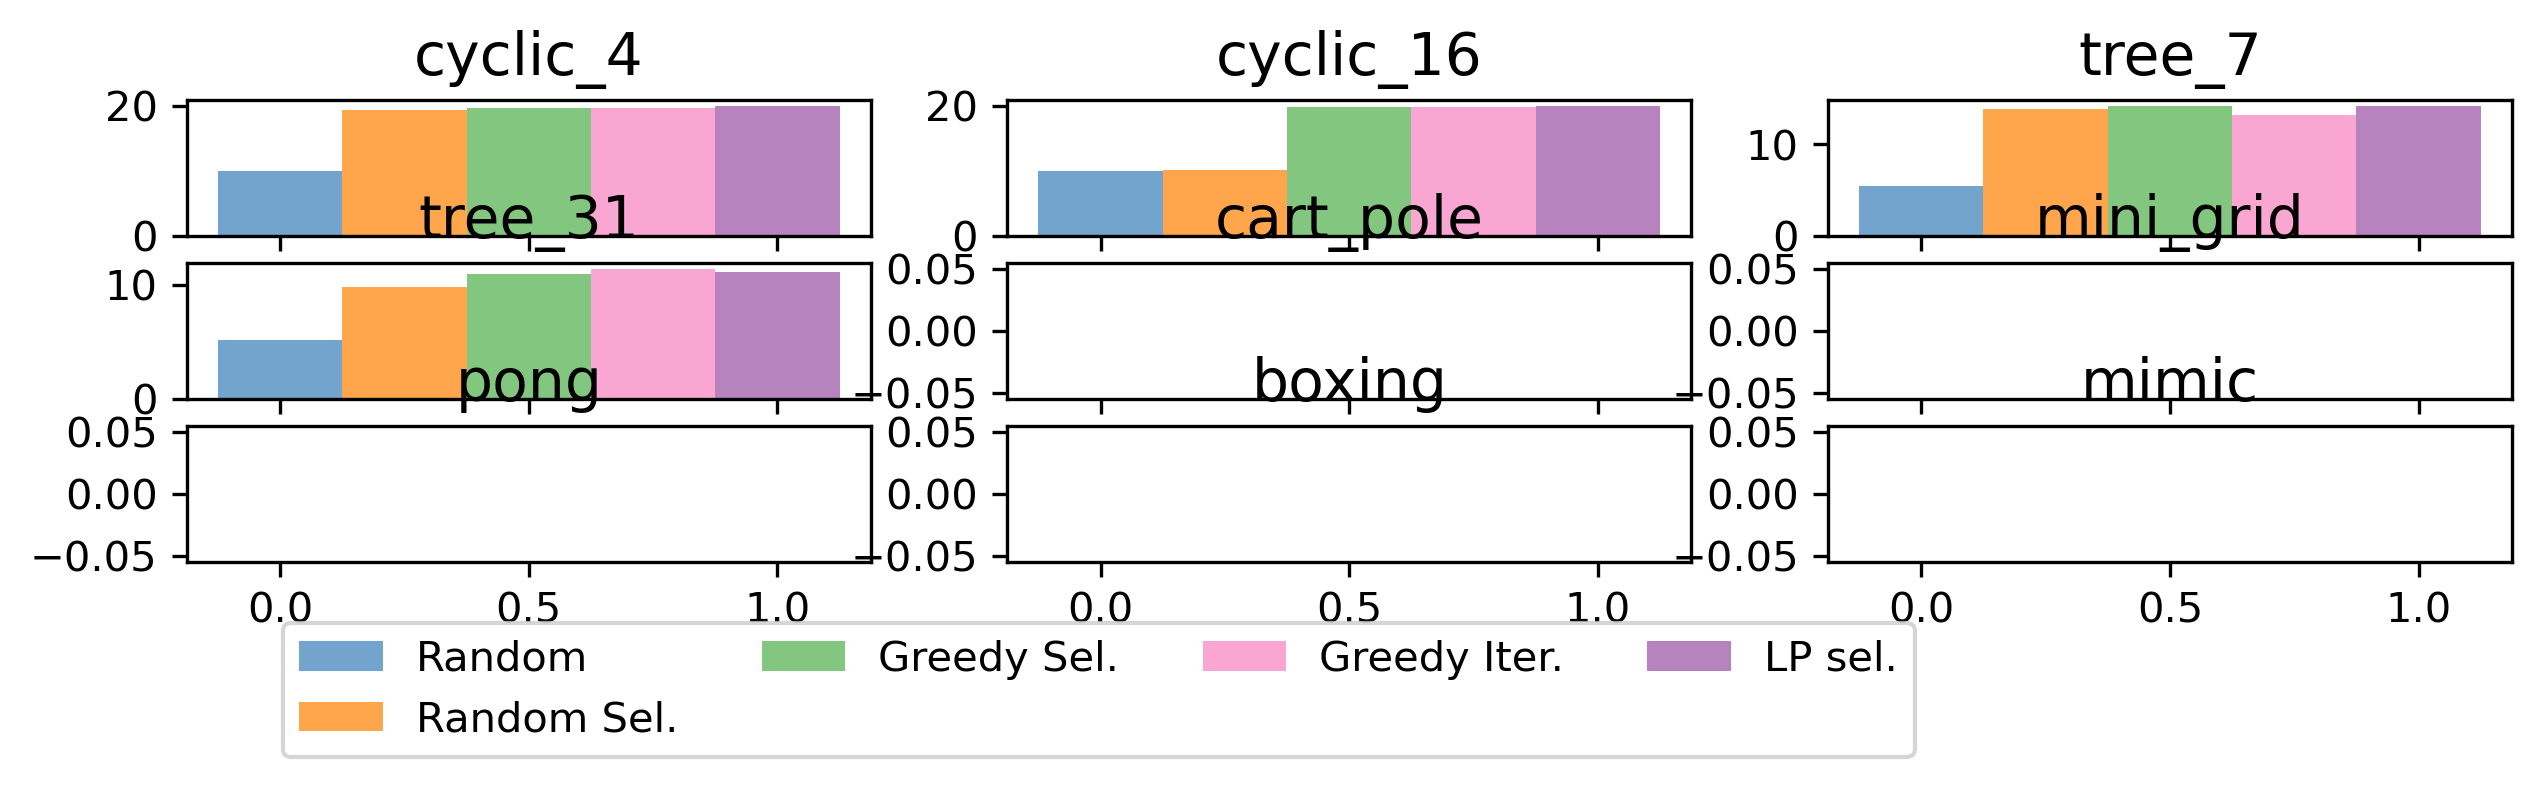

In [7]:
# Plot Comparison for each env
plot_dimensions = (3,3)
def index_to_tuple(i):
    return (i//3,i%3)

def flatten_to_square(lst):
    res = [[0 for i in range(3)] for j in range(3)]

    for i in range(len(lst)):
        x,y = index_to_tuple(i)
        res[x][y] = lst[i]
    
    return res

titles = flatten_to_square(environments)

sup_y_label = ""
overall_format = {'figsize':(10,2),
    'style_size': style_size,
    'has_grid': False, 
}

fig,ax = create_axes(plot_dimensions,overall_format,titles=titles)

bar_format = {'color_palette': 'six_color', 'linewidth': 10, 'style_size': style_size}
plt.tight_layout()

num_by_env = {
    "cyclic_4": 3, 
    "cyclic_16": 2,
    "tree_7": 2, 
    "tree_31": 2, 
    "cart_pole": 8, 
    "mini_grid": 20,
    "pong": 25,
    "boxing": 30,
    "mimic": 70,
}

for i in range(len(environments)):
    x_groups = list(range(5))
    idx = number_concepts.index(num_by_env[environments[i]])
    y_vals = [random_results[i][idx],random_selection[i][idx],
                greedy_selection[i][idx],greedy_iterative_selection[i][idx],
                lp_selection[i][idx]]
    print(environments[i],y_vals)
    x,y = index_to_tuple(i)

    d = {
        0: 'Random',
        1: 'Random Sel.',
        2: 'Greedy Sel.',
        3: 'Greedy Iter.',
        4: 'LP sel.'
    }

    plot_bar(ax[x][y],x_groups,y_vals,[0 for i in range(len(y_vals))], d,bar_format)

legend_format = {'style_size': style_size,'type': 'is_global', 'loc': 'lower left', 'ncol': 4, 'bbox_to_anchor': (0.15,-0.25),'fontsize': 14}
create_legend(fig,ax,plot_dimensions,legend_format)
fig.savefig("../../results/figures/basic_comparison_methods.pdf",dpi=300, bbox_inches='tight')

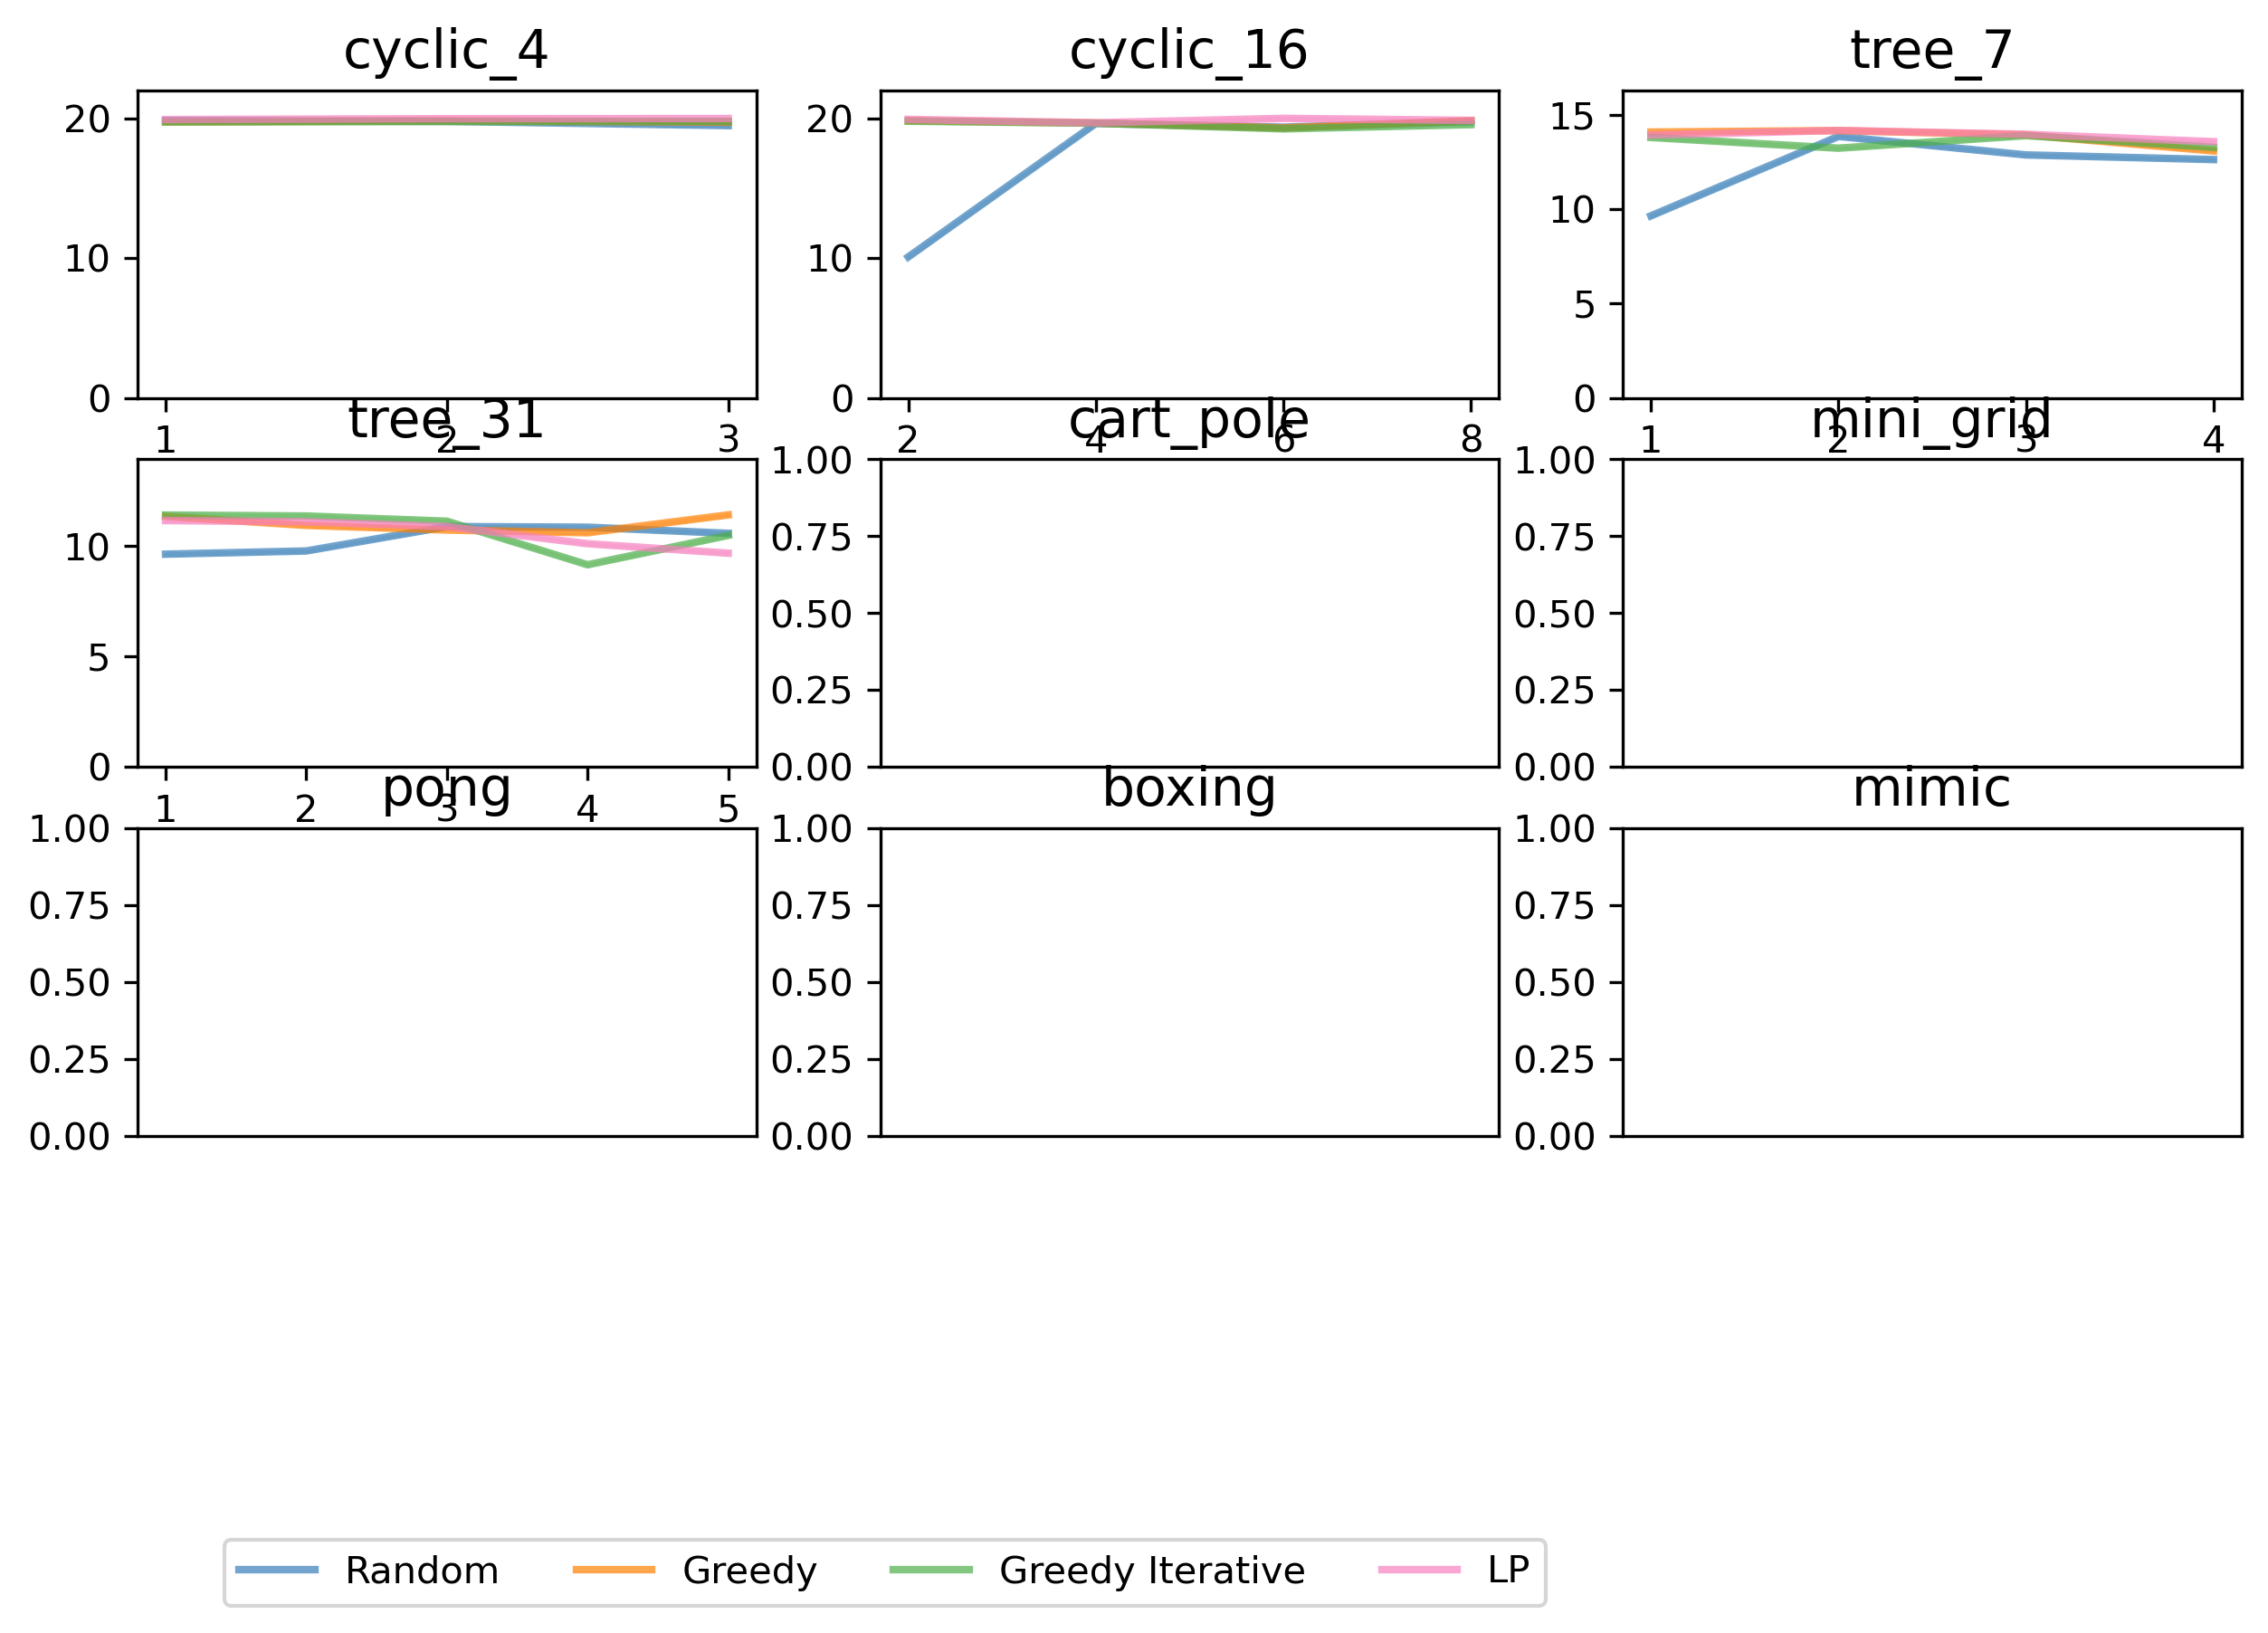

In [8]:
# Plot #concpet perf. 
# Plot Comparison for each env
plot_dimensions = (3,3)
def index_to_tuple(i):
    return (i//3,i%3)

def flatten_to_square(lst):
    res = [[0 for i in range(3)] for j in range(3)]

    for i in range(len(lst)):
        x,y = index_to_tuple(i)
        res[x][y] = lst[i]
    
    return res

num_by_env = {
    "cyclic_4": [1,2,3], 
    "cyclic_16": [2,4,6,8],
    "tree_7": [1,2,3,4], 
    "tree_31": [1,2,3,4,5], 
    "cart_pole": [], 
    "mini_grid": [],
    "pong": [],
    "boxing": [],
    "mimic": [],
}

titles = flatten_to_square(environments)

sup_y_label = ""
overall_format = {'figsize':(10,5),
    'style_size': style_size,
    'has_grid': False, 
    'y_lim': [[[0,22],[0,22],[0,(10*4/7+20*3/7)+2]],[[0,(10*25/31+20*6/31)+2],[0,1],[0,1]],[[0,1],[0,1],[0,1]]],
    'x_ticks': [[[num_by_env[environments[3*i+j]],num_by_env[environments[3*i+j]]] for j in range(3)] for i in range(3)]
}

fig,ax = create_axes(plot_dimensions,overall_format,titles=titles)

line_format = {'color_palette': 'six_color', 'linewidth': 2}

all_labels = ["Random","Greedy","Greedy Iterative","LP"]

for i in range(len(environments)):
    x_groups = [num_by_env[environments[i]] for arr in [random_selection,greedy_selection,greedy_iterative_selection,lp_selection]]
    x_vals = num_by_env[environments[i]]
    y_vals = [[arr[i][number_concepts.index(j)] for j in num_by_env[environments[i]]] for arr in [random_selection,greedy_selection,greedy_iterative_selection,lp_selection]]
    x,y = index_to_tuple(i)

    plot_line(ax[x][y],x_groups,y_vals,[[0 for i in range(len(arr))] for arr in y_vals],all_labels,line_format)

legend_format = {'style_size': style_size,'type': 'is_global', 'loc': 'lower left', 'ncol': 4, 'bbox_to_anchor': (0.15,-0.25),'fontsize': 14}
create_legend(fig,ax,plot_dimensions,legend_format)
fig.savefig("../../results/figures/number_of_concepts_basic.pdf",dpi=300, bbox_inches='tight')

## Imperfect Concepts

In [15]:
training_times = {
    'cyclic_4':10_000,
    'cyclic_16':10_000,
    'tree_7': 25_000, 
    'tree_31': 25_000,
    'cart_pole': 250000,
    'mini_grid': 12_000_000,
    'pong': 12_000_000,
    'boxing': 12_000_000,
    'mimic': 250000,
}

In [16]:
fixed_accuracies = [[0.5,0.75,0.9],[0.5,0.75,0.9]]+[[0.5,0.75,0.9,0.95] for i in range(7)]
num_concepts_selected = [2,2,2,2]
num_concepts = [3,15,4,6]
environments = ["cyclic_4","cyclic_16","tree_7","tree_31"]

greedy_selection = [[0 for i in range(len(fixed_accuracies[i]))] for i in range(len(environments))]
lp_selection = [[0 for i in range(len(fixed_accuracies[i]))] for i in range(len(environments))]
imperfect_selection = [[0 for i in range(len(fixed_accuracies[i]))] for i in range(len(environments))]
multiple_selection = [[0 for i in range(len(fixed_accuracies[i]))] for i in range(len(environments))]
for j,e in enumerate(environments):
    for i,n in enumerate(fixed_accuracies[j]):
        matching_params = get_results_matching_parameters("imperfect","",{'environment_string': e,'num_concepts_selected': num_concepts_selected[j], 
                        'training_timesteps': training_times[e], 'concept_source': 'human_selected_binary', 'run_intervention': False,
                        'cbm_accuracy_by_concept': [n for i in range(num_concepts[j])]})
        assert len(matching_params) <= 3
        if len(matching_params) > 0 and 'inaccurate_comparison' in matching_params[0] and 'multiple_lp' in matching_params[0]['inaccurate_comparison']:
            imperfect_comparison = matching_params[0]['inaccurate_comparison']
            res = [
                [i['inaccurate_comparison']['greedy']['binary']['reward'] for i in matching_params],
                [i['inaccurate_comparison']['lp']['binary']['reward'] for i in matching_params],
                [i['inaccurate_comparison']['imperfect_lp']['binary']['reward'] for i in matching_params],
                [i['inaccurate_comparison']['multiple_lp']['reward'] for i in matching_params],
            ]

        else:
            res = [[0],[0],[0],[0]]

        greedy_selection[j][i] = res[0]
        lp_selection[j][i] = res[1]
        imperfect_selection[j][i] = res[2]
        multiple_selection[j][i] = res[3]

        

[0.61126691 1.04157775 0.38384647]
[0.05203684 0.5640079  0.27449051]
[0.04843797 0.07112321 0.63296782 0.75351751]
[0.11425694 0.06545776 0.09518568 0.16026141]


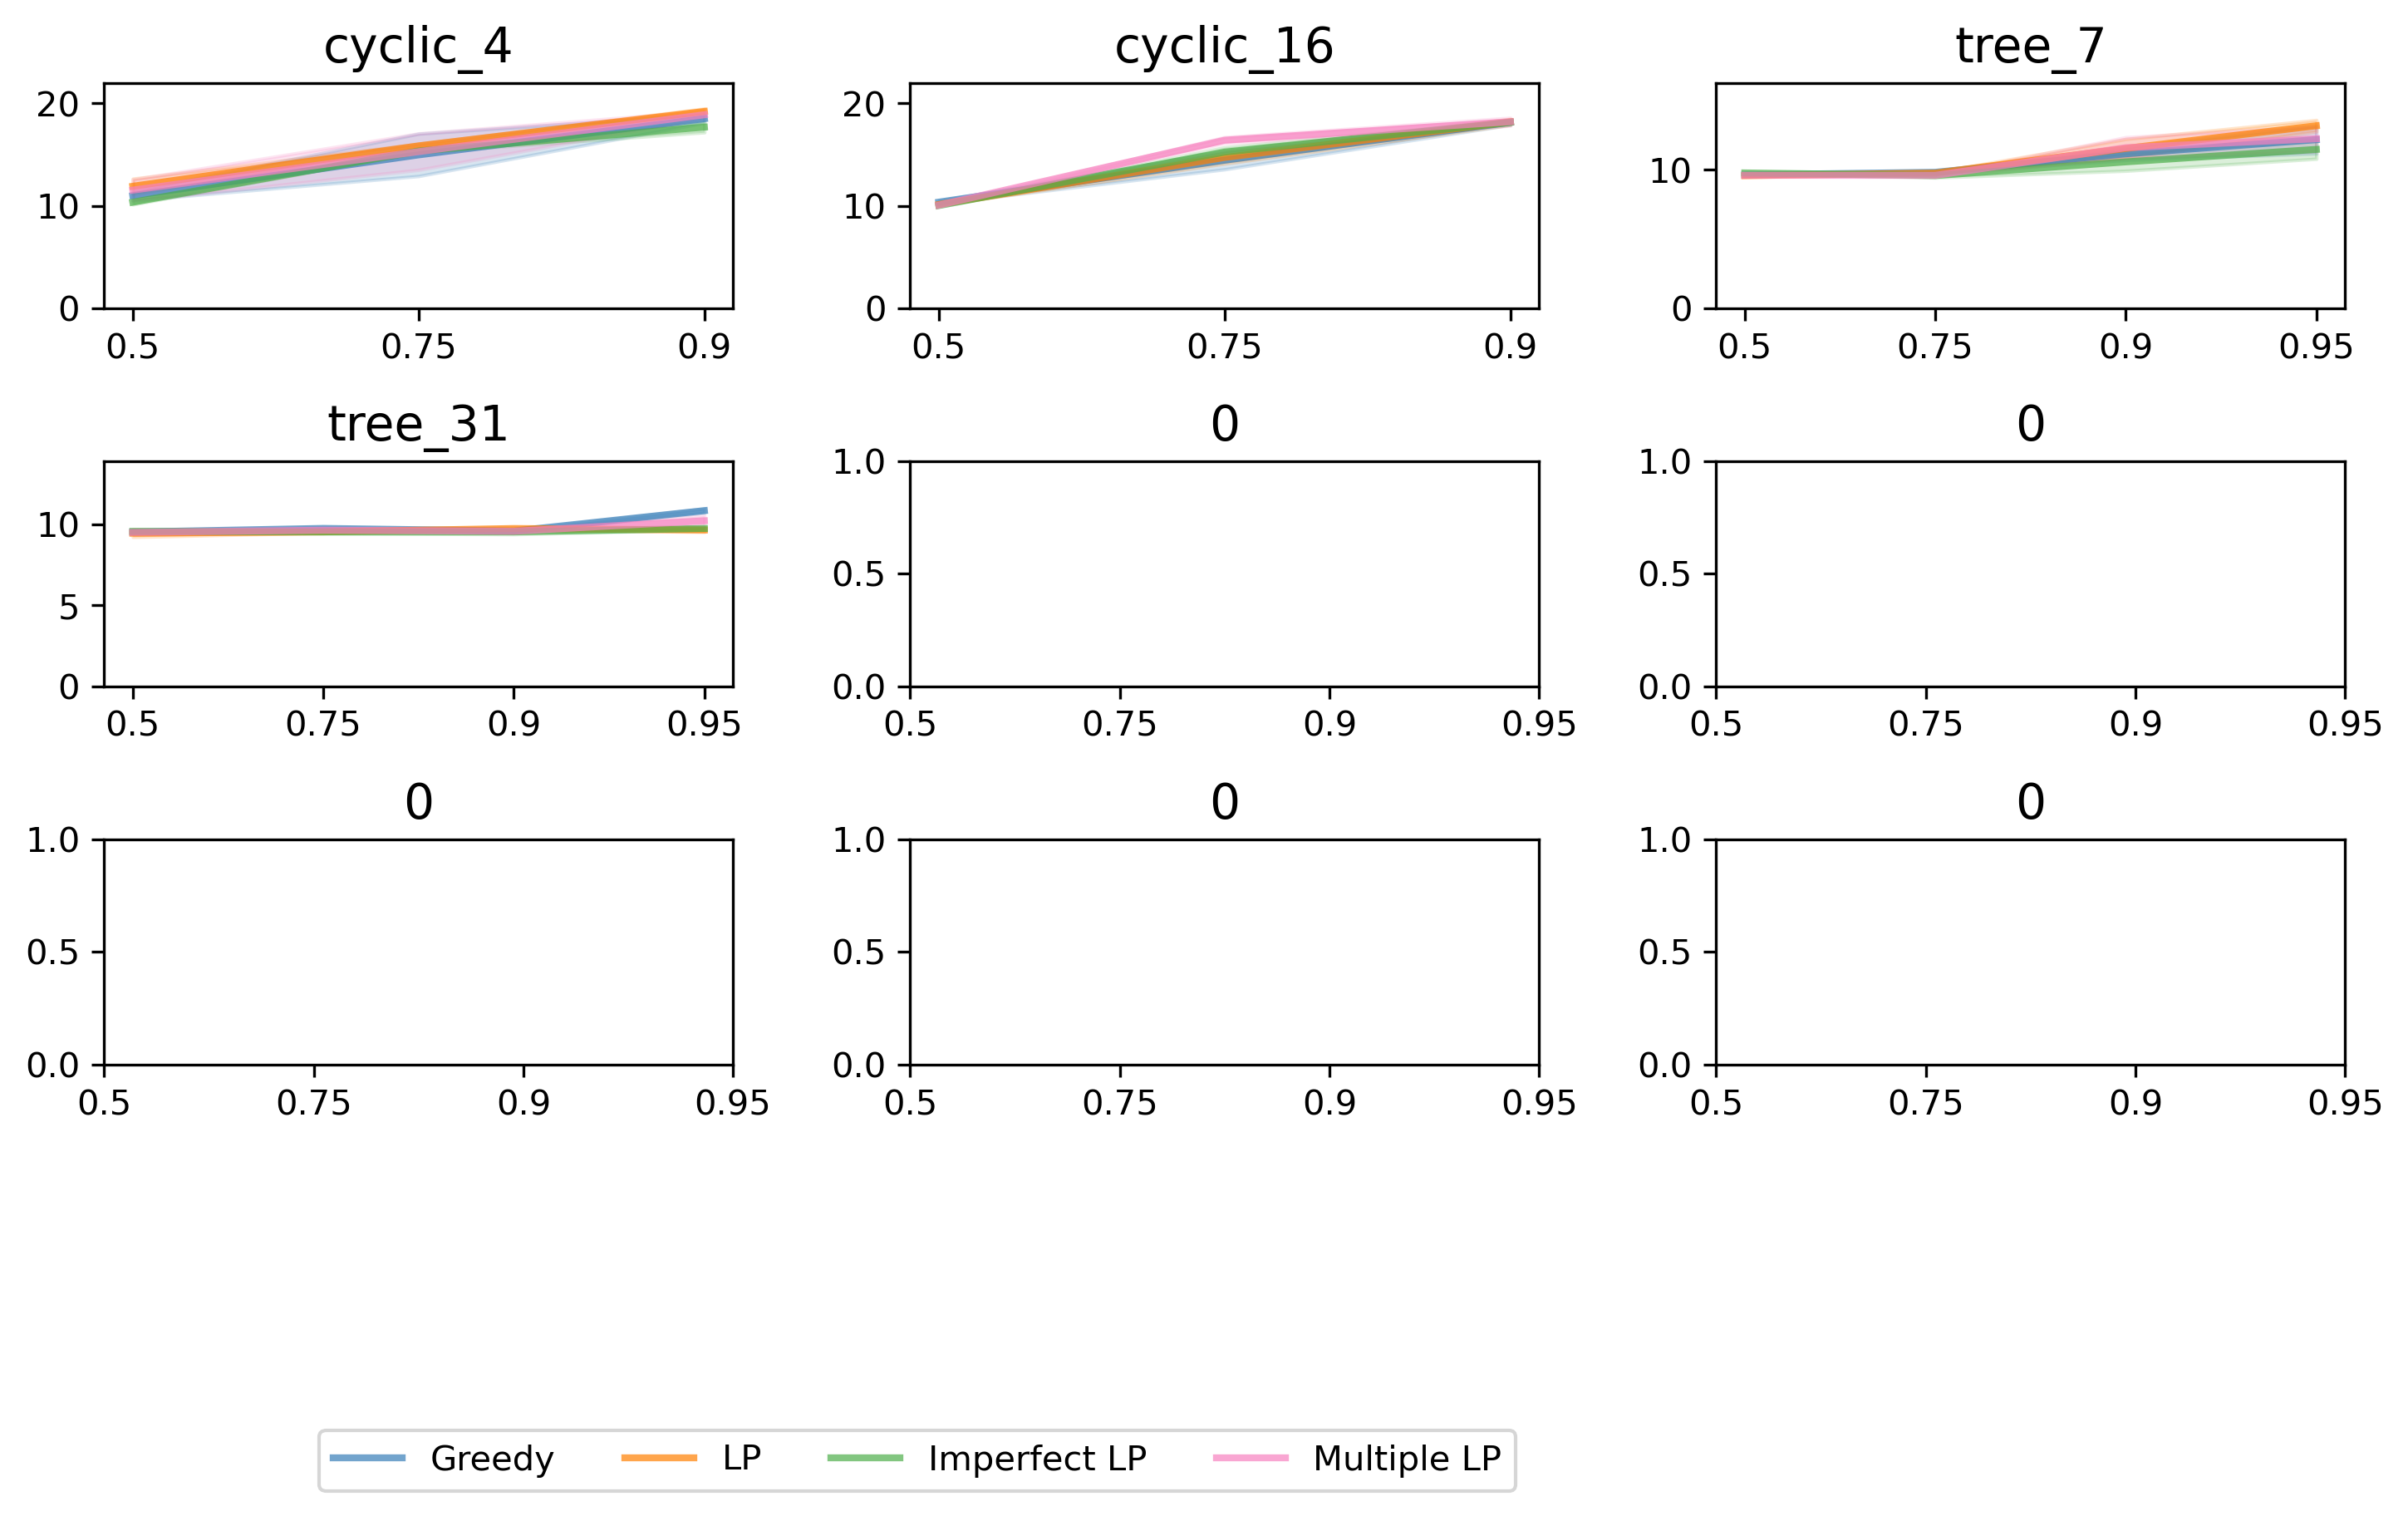

In [17]:
# Plot #concpet perf. 
# Plot Comparison for each env
plot_dimensions = (3,3)
def index_to_tuple(i):
    return (i//3,i%3)

def flatten_to_square(lst):
    res = [[0 for i in range(3)] for j in range(3)]

    for i in range(len(lst)):
        x,y = index_to_tuple(i)
        res[x][y] = lst[i]
    
    return res

titles = flatten_to_square(environments)

sup_y_label = ""
overall_format = {'figsize':(10,5),
    'style_size': style_size,
    'has_grid': False, 
    'y_lim': [[[0,22],[0,22],[0,(10*4/7+20*3/7)+2]],[[0,(10*25/31+20*6/31)+2],[0,1],[0,1]],[[0,1],[0,1],[0,1]]],
    'x_ticks': [[[list(range(len(fixed_accuracies[3*i+j]))),fixed_accuracies[3*i+j]] for j in range(3)] for i in range(3)]
}

fig,ax = create_axes(plot_dimensions,overall_format,titles=titles)

line_format = {'color_palette': 'six_color', 'linewidth': 2}
plt.tight_layout()

all_labels = ["Greedy","LP","Imperfect LP","Multiple LP"]

for i in range(len(environments)):
    x_groups = [list(range(len(arr[i]))) for arr in [greedy_selection,lp_selection,imperfect_selection,multiple_selection]]
    y_vals = [[np.mean(arr[i][j]) for j in range(len(arr[i]))] for arr in [greedy_selection,lp_selection,imperfect_selection,multiple_selection]]
    y_std = [[np.std(arr[i][j])/len(arr[i][j])**.5 for j in range(len(arr[i]))] for arr in [greedy_selection,lp_selection,imperfect_selection,multiple_selection
                                                                                            ]]
    x,y = index_to_tuple(i)
    plot_line(ax[x][y],x_groups,y_vals,y_std,all_labels,line_format)
    print(np.mean(y_std,axis=0))
legend_format = {'style_size': style_size,'type': 'is_global', 'loc': 'lower left', 'ncol': 4, 'bbox_to_anchor': (0.15,-0.25),'fontsize': 14}
create_legend(fig,ax,plot_dimensions,legend_format)
fig.savefig("../../results/figures/imperfect_comparison.pdf",dpi=300, bbox_inches='tight')

In [12]:
fixed_accuracy=[0.75,0.75,0.95,0.95]
num_concepts_selected = [[1,2,3],[1,2,3,4],[1,2,3,4],[1,2,3,4]]
num_concepts = [3,15,4,6]
environments = ["cyclic_4","cyclic_16","tree_7","tree_31"]

greedy_selection = [[0 for i in range(len(num_concepts_selected[i]))] for i in range(len(environments))]
lp_selection = [[0 for i in range(len(num_concepts_selected[i]))] for i in range(len(environments))]
imperfect_selection = [[0 for i in range(len(num_concepts_selected[i]))] for i in range(len(environments))]
multiple_selection = [[0 for i in range(len(num_concepts_selected[i]))] for i in range(len(environments))]

for j,e in enumerate(environments):
    for i,n in enumerate(num_concepts_selected[j]):
        matching_params = get_results_matching_parameters("imperfect","",{'environment_string': e,'num_concepts_selected': n, 
                        'training_timesteps': training_times[e], 'concept_source': 'human_selected_binary', 'run_intervention': False,
                        'cbm_accuracy_by_concept': [fixed_accuracy[j] for i in range(num_concepts[j])]})
        assert len(matching_params) <= 3
        if len(matching_params) > 0 and 'inaccurate_comparison' in matching_params[0] and 'multiple_lp' in matching_params[0]['inaccurate_comparison']:
            res = [
                [i['inaccurate_comparison']['greedy']['binary']['reward'] for i in matching_params],
                [i['inaccurate_comparison']['lp']['binary']['reward'] for i in matching_params],
                [i['inaccurate_comparison']['imperfect_lp']['binary']['reward'] for i in matching_params],
                [i['inaccurate_comparison']['multiple_lp']['reward'] for i in matching_params],
            ]

        else:
            res = [[0],[0],[0],[0]]

        greedy_selection[j][i] = res[0]
        lp_selection[j][i] = res[1]
        imperfect_selection[j][i] = res[2]
        multiple_selection[j][i] = res[3]

        

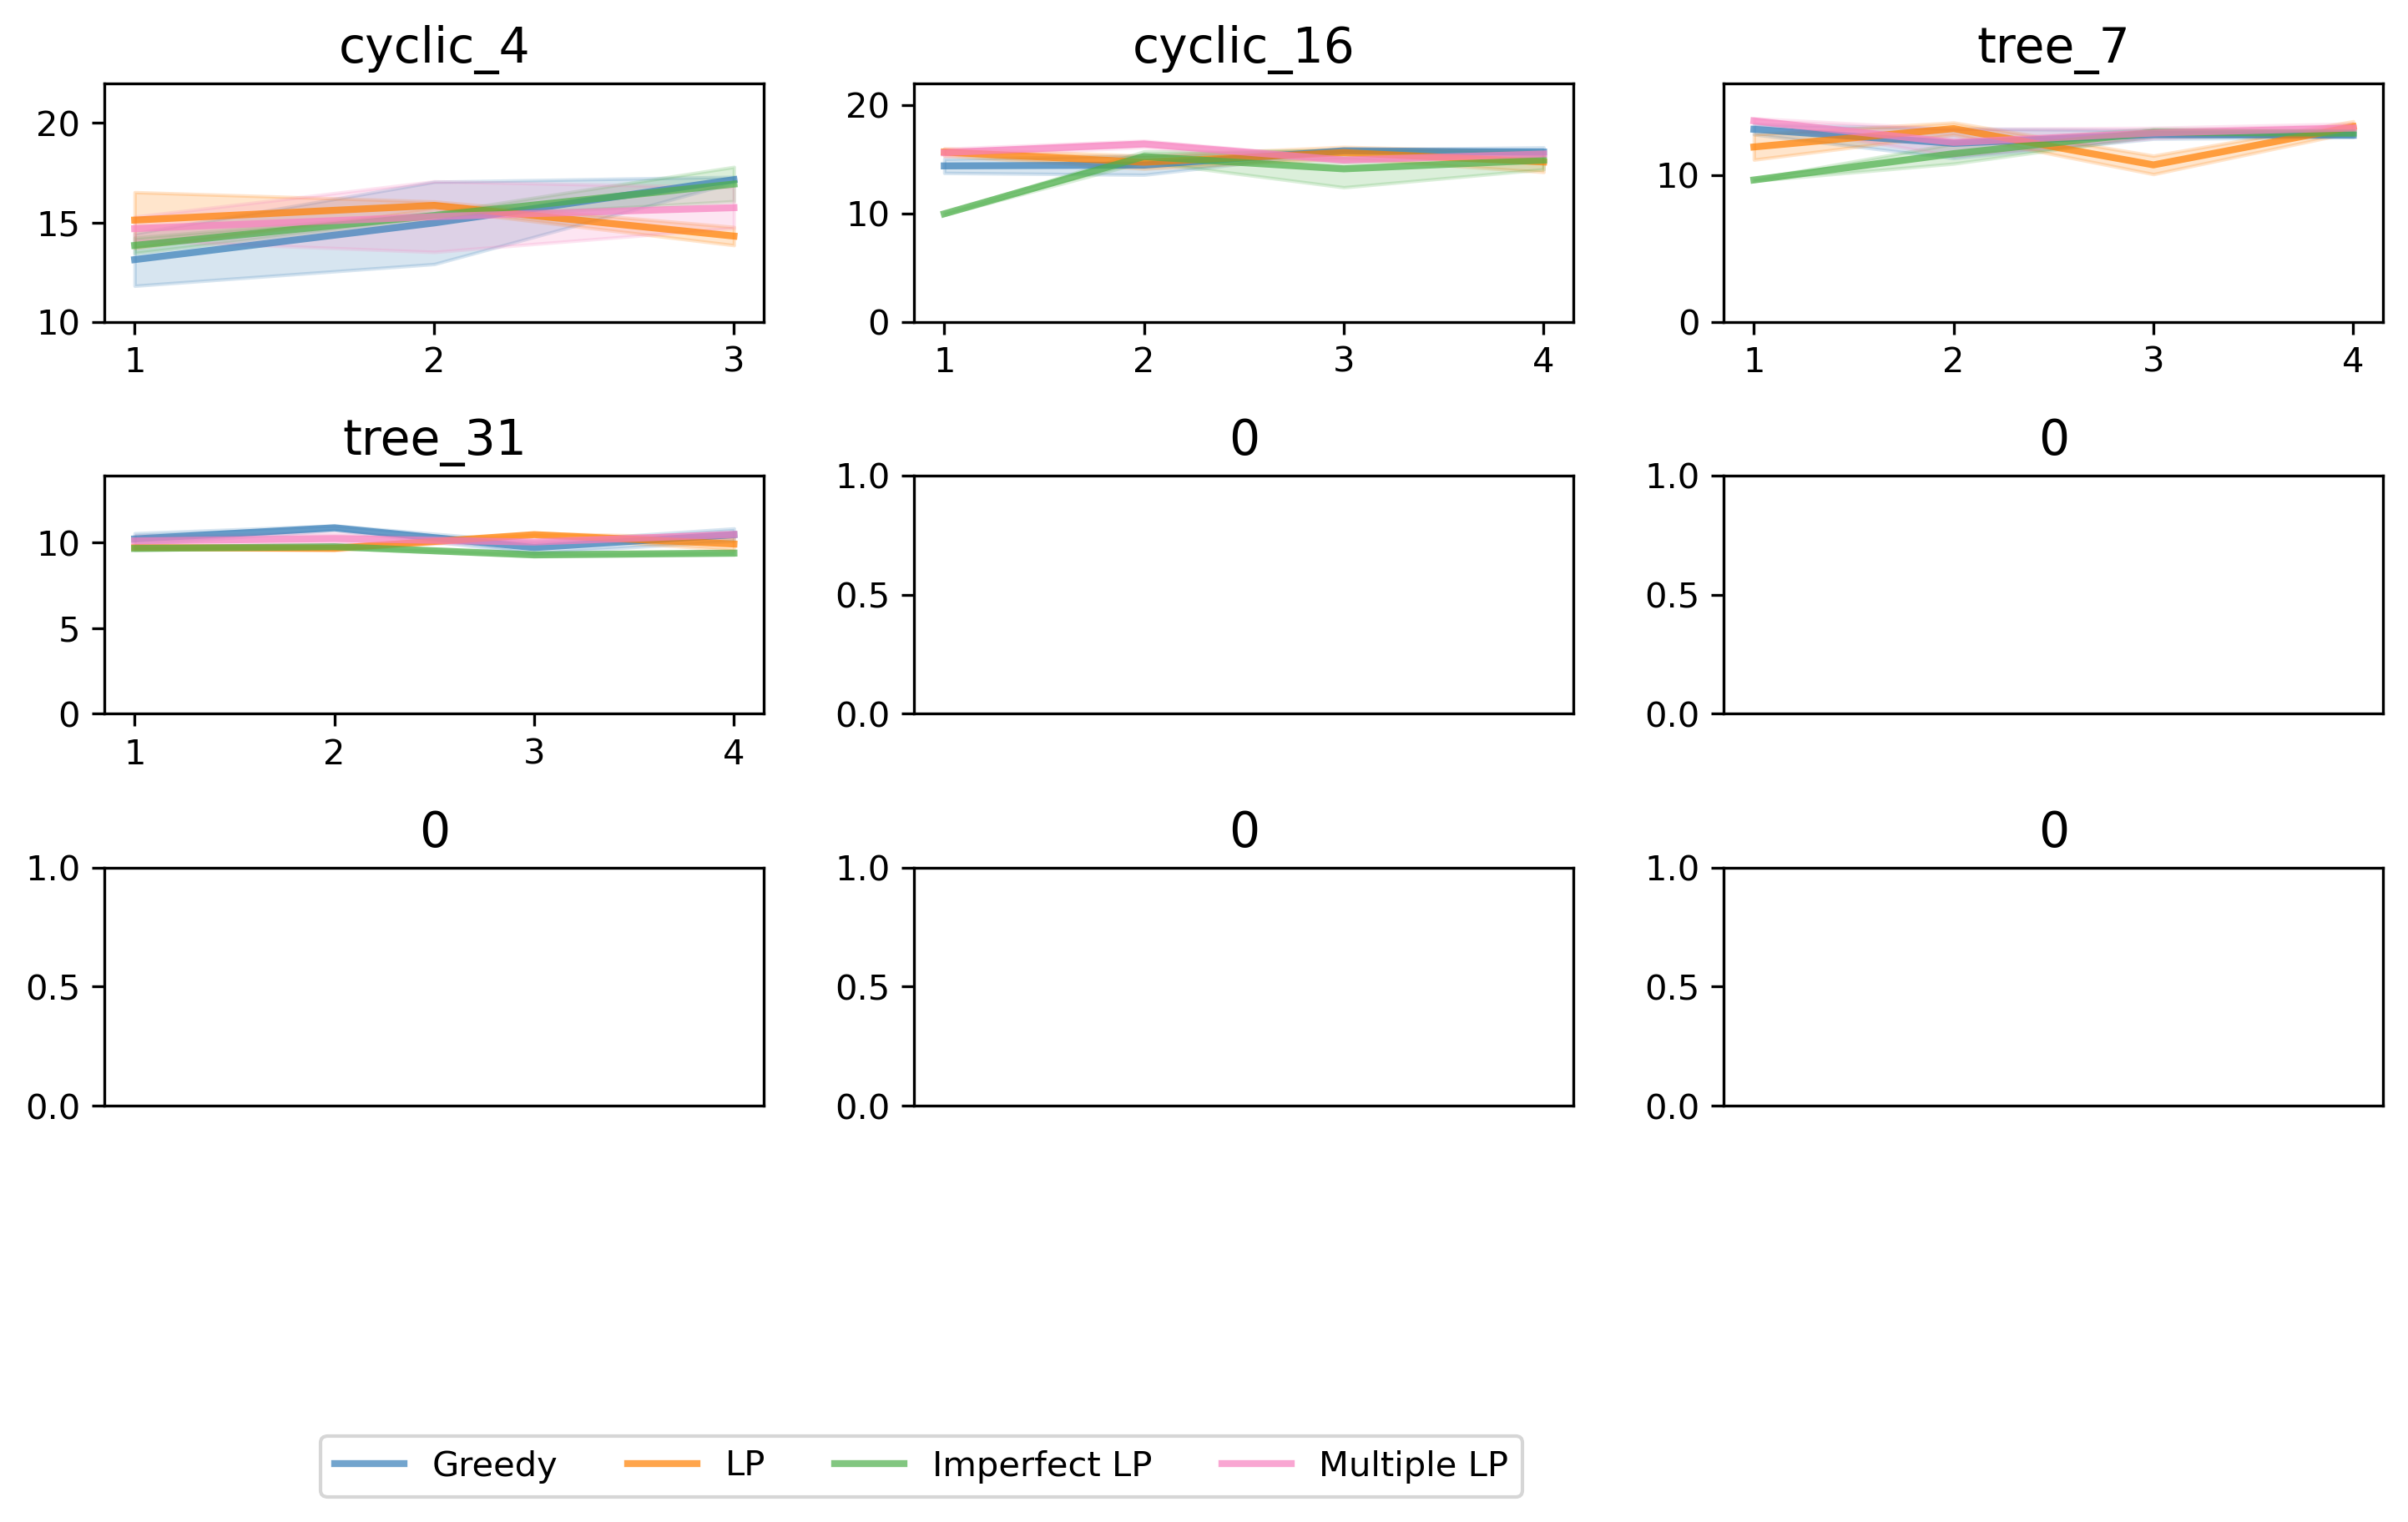

In [13]:
# Plot #concpet perf. 
# Plot Comparison for each env
plot_dimensions = (3,3)
def index_to_tuple(i):
    return (i//3,i%3)

def flatten_to_square(lst):
    res = [[0 for i in range(3)] for j in range(3)]

    for i in range(len(lst)):
        x,y = index_to_tuple(i)
        res[x][y] = lst[i]
    
    return res

titles = flatten_to_square(environments)
x_ticks = flatten_to_square(num_concepts_selected)

sup_y_label = ""
overall_format = {'figsize':(10,5),
    'style_size': style_size,
    'has_grid': False, 
    'y_lim': [[[10,22],[0,22],[0,(10*4/7+20*3/7)+2]],[[0,(10*25/31+20*6/31)+2],[0,1],[0,1]],[[0,1],[0,1],[0,1]]],
    'x_ticks': [[[list(range(len(j))),j] if j!=0 else [[],[]] for j in i] for i in x_ticks]
}

fig,ax = create_axes(plot_dimensions,overall_format,titles=titles)

line_format = {'color_palette': 'six_color', 'linewidth': 2}
plt.tight_layout()

all_labels = ["Greedy","LP","Imperfect LP","Multiple LP"]

for i in range(len(environments)):
    x_groups = [list(range(len(arr[i]))) for arr in [greedy_selection,lp_selection,imperfect_selection,multiple_selection]]
    x_vals = num_concepts_selected[i]
    y_vals = [[np.mean(arr[i][j]) for j in range(len(arr[i]))] for arr in [greedy_selection,lp_selection,imperfect_selection,multiple_selection]]
    y_std = [[np.std(arr[i][j])/len(arr[i][j])**.5 for j in range(len(arr[i]))] for arr in [greedy_selection,lp_selection,imperfect_selection,multiple_selection]]
    x,y = index_to_tuple(i)
    plot_line(ax[x][y],x_groups,y_vals,y_std,all_labels,line_format)

legend_format = {'style_size': style_size,'type': 'is_global', 'loc': 'lower left', 'ncol': 4, 'bbox_to_anchor': (0.15,-0.25),'fontsize': 14}
create_legend(fig,ax,plot_dimensions,legend_format)
fig.savefig("../../results/figures/imperfect_comparison.pdf",dpi=300, bbox_inches='tight')

### Intervention

In [18]:
intervention_probability = [0.25,0.5,0.75]
num_concepts_selected = [2,2,2,2]
fixed_accuracies = [[0.5,0.75,0.75],[0.5,0.75,0.75,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5],[0.75,0.75,0.75,0.5],[0.75,0.75,0.75,0.75,0.75,0.5]]
environments = ["cyclic_4","cyclic_16","tree_7","tree_31"]

greedy_selection = [[0 for i in range(len(intervention_probability))] for i in range(len(environments))]
lp_selection = [[0 for i in range(len(intervention_probability))] for i in range(len(environments))]
imperfect_selection = [[0 for i in range(len(intervention_probability))] for i in range(len(environments))]
multiple_selection = [[0 for i in range(len(intervention_probability))] for i in range(len(environments))]

for i,n in enumerate(intervention_probability):
    for j,e in enumerate(environments):
        matching_params = get_results_matching_parameters("intervention","",{'environment_string': e,'num_concepts_selected': num_concepts_selected[j], 
                        'training_timesteps': training_times[e], 'concept_source': 'human_selected_binary', 'run_intervention': True,
                        'intervention_probability': n,'cbm_accuracy_by_concept': fixed_accuracies[j]})
        if len(matching_params) > 0:
            res = [
                [i['intervention_comparison']['greedy']['binary']['reward'] for i in matching_params],
                [i['intervention_comparison']['lp']['binary']['reward'] for i in matching_params],
                [i['intervention_comparison']['imperfect_lp']['binary']['reward'] for i in matching_params],
                [i['intervention_comparison']['multiple_lp']['reward'] for i in matching_params],
            ]

        else:
            res = [[0],[0],[0],[0]]

        greedy_selection[j][i] = res[0]
        lp_selection[j][i] = res[1]
        imperfect_selection[j][i] = res[2]
        multiple_selection[j][i] = res[3]

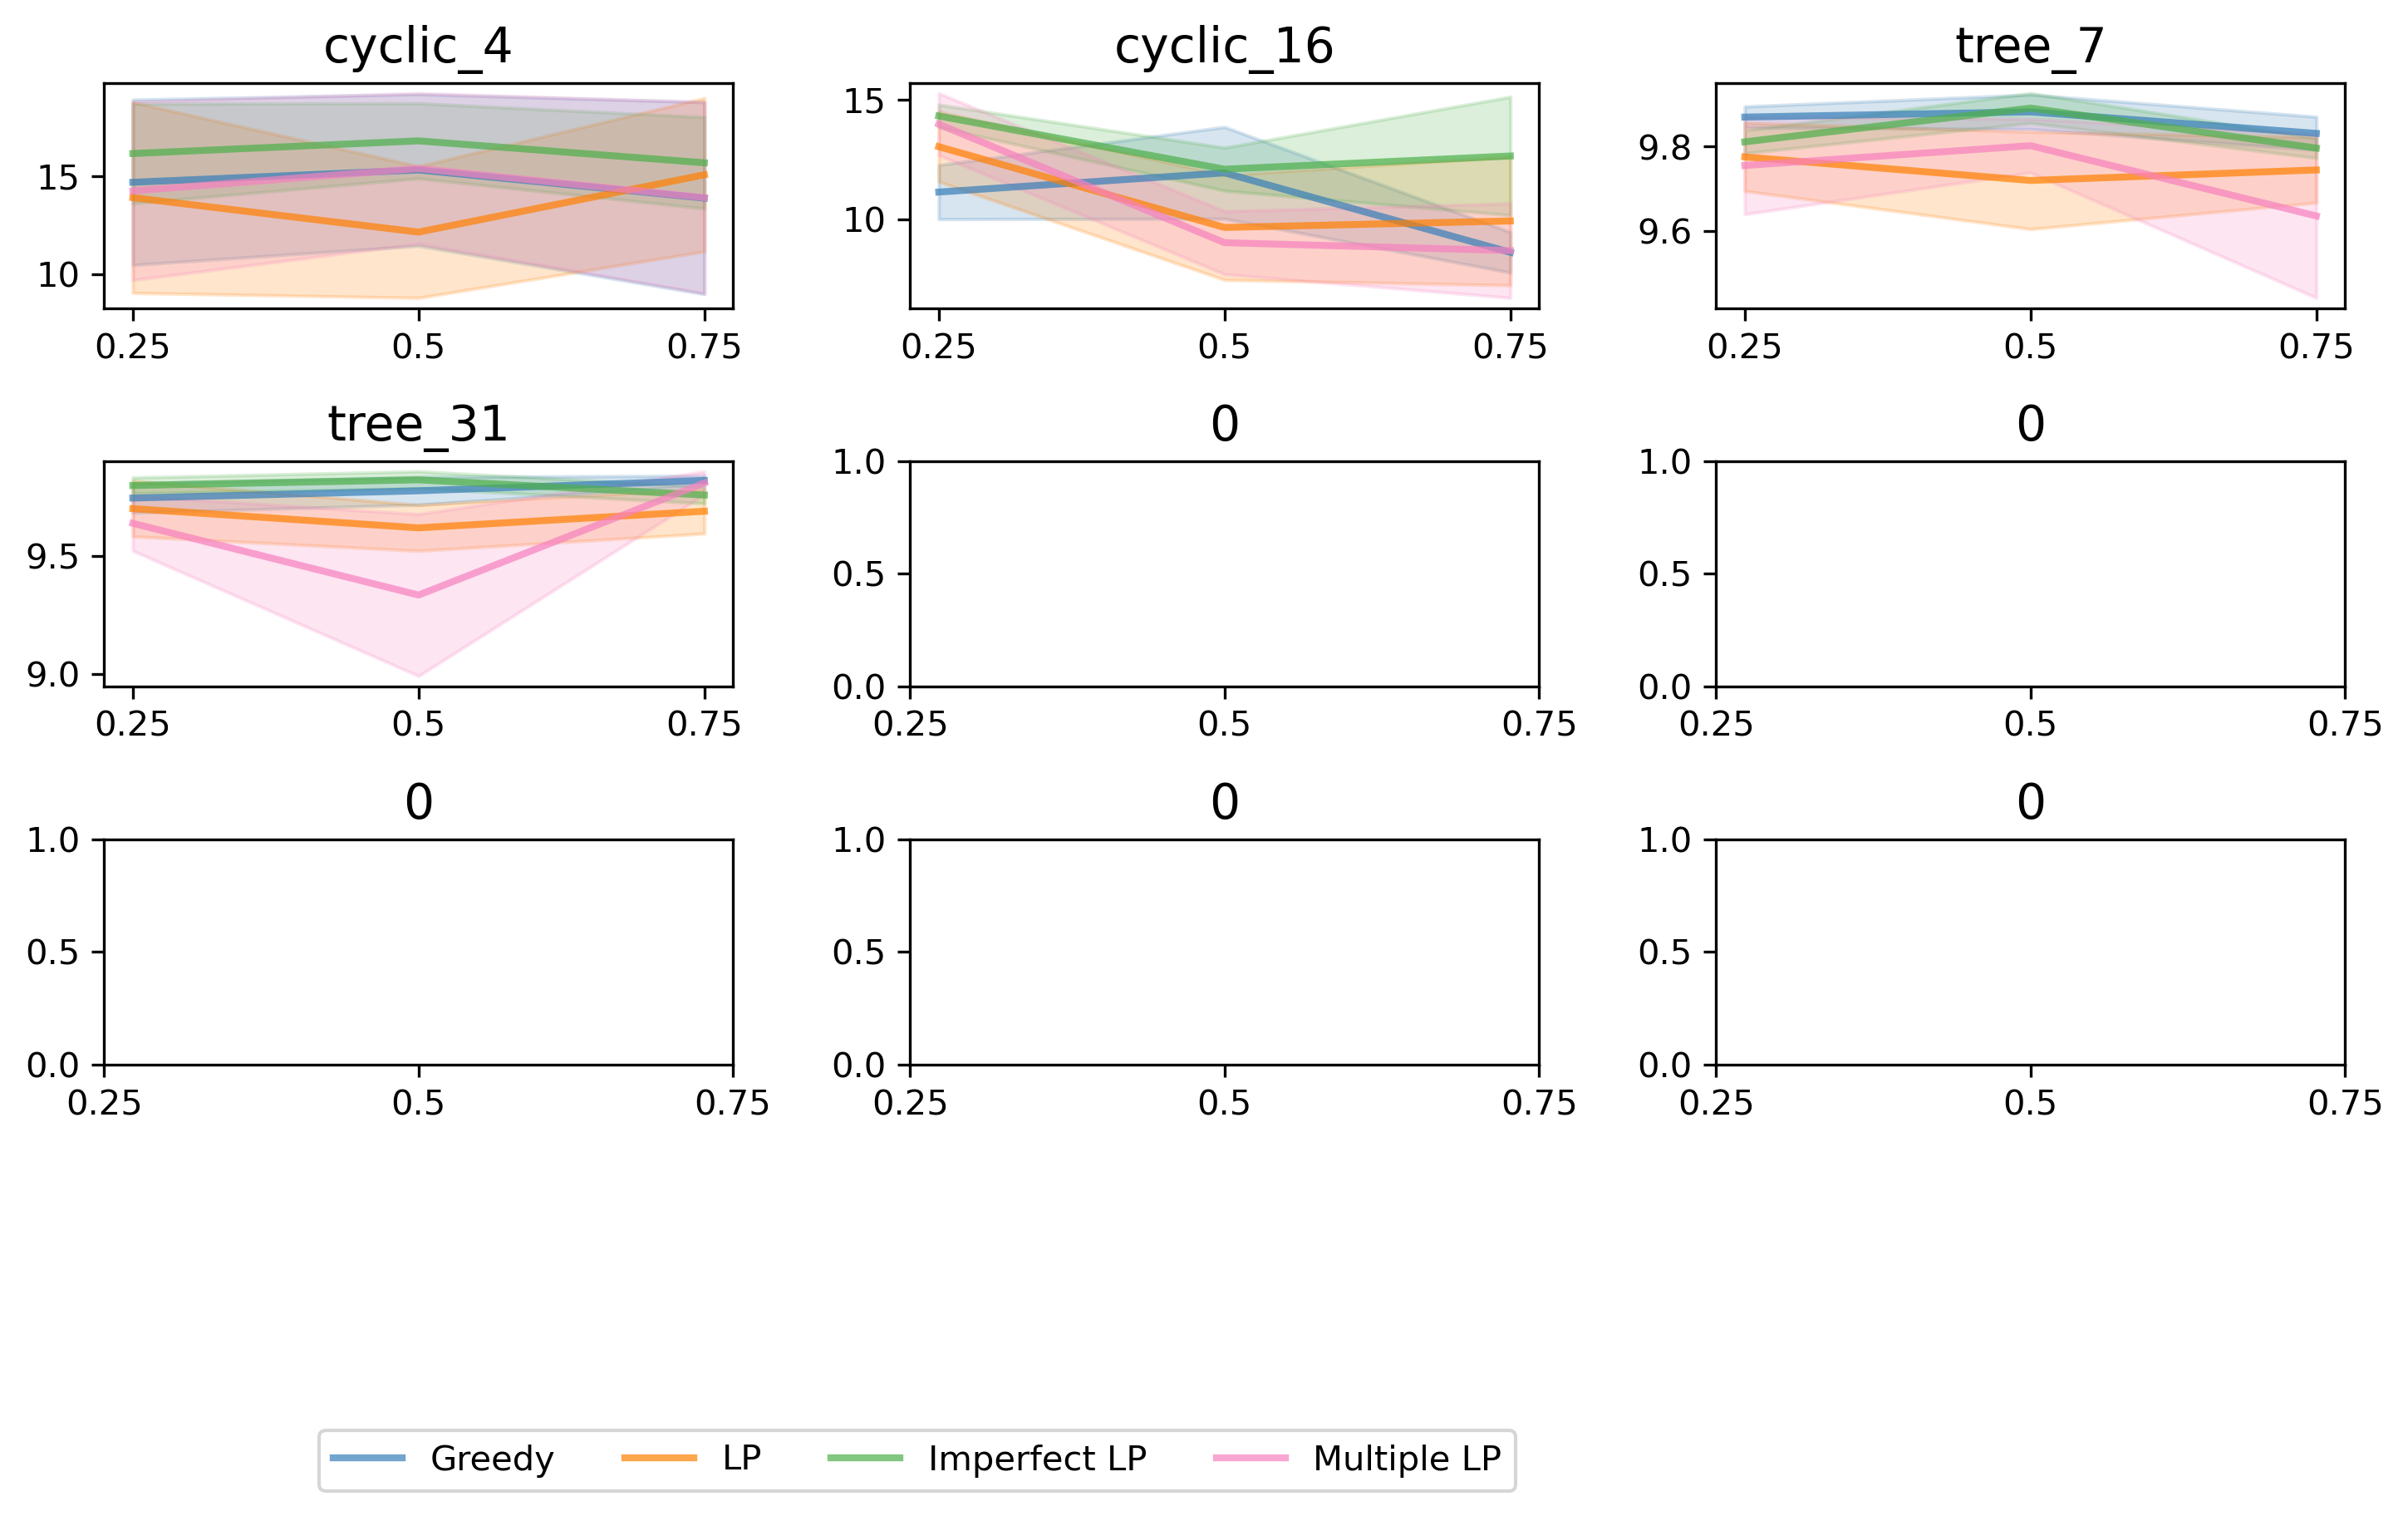

In [19]:
# Plot #concpet perf. 
# Plot Comparison for each env
plot_dimensions = (3,3)
def index_to_tuple(i):
    return (i//3,i%3)

def flatten_to_square(lst):
    res = [[0 for i in range(3)] for j in range(3)]

    for i in range(len(lst)):
        x,y = index_to_tuple(i)
        res[x][y] = lst[i]
    
    return res

titles = flatten_to_square(environments)

sup_y_label = ""
overall_format = {'figsize':(10,5),
    'style_size': style_size,
    'has_grid': False, 
    'x_ticks': [[[list(range(len(intervention_probability))),intervention_probability] for i in range(3)] for j in range(3)]

}

fig,ax = create_axes(plot_dimensions,overall_format,titles=titles)

line_format = {'color_palette': 'six_color', 'linewidth': 2}
plt.tight_layout()

all_labels = ["Greedy","LP","Imperfect LP","Multiple LP"]

for i in range(len(environments)):
    x_groups = [list(range(len(arr[i]))) for arr in [greedy_selection,lp_selection,imperfect_selection,multiple_selection]]
    x_vals = num_concepts_selected[i]
    y_vals = [[np.mean(arr[i][j]) for j in range(len(arr[i]))] for arr in [greedy_selection,lp_selection,imperfect_selection,multiple_selection]]
    y_std = [[np.std(arr[i][j])/len(arr[i][j])**.5 for j in range(len(arr[i]))] for arr in [greedy_selection,lp_selection,imperfect_selection,multiple_selection]]
    x,y = index_to_tuple(i)
    plot_line(ax[x][y],x_groups,y_vals,y_std,all_labels,line_format)

legend_format = {'style_size': style_size,'type': 'is_global', 'loc': 'lower left', 'ncol': 4, 'bbox_to_anchor': (0.15,-0.25),'fontsize': 14}
create_legend(fig,ax,plot_dimensions,legend_format)
fig.savefig("../../results/figures/intervention_comparison.pdf",dpi=300, bbox_inches='tight')

In [20]:
intervention_probability = [0.25,0.5,0.75]
num_concepts_selected = [2,2,2,2]
fixed_accuracies = [[0.5,0.95,0.95],[0.5,0.95,0.95,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5],[0.95,0.95,0.95,0.5],[0.95,0.95,0.95,0.95,0.95,0.5]]
environments = ["cyclic_4","cyclic_16","tree_7","tree_31"]

greedy_selection = [[0 for i in range(len(intervention_probability))] for i in range(len(environments))]
lp_selection = [[0 for i in range(len(intervention_probability))] for i in range(len(environments))]
imperfect_selection = [[0 for i in range(len(intervention_probability))] for i in range(len(environments))]
multiple_selection = [[0 for i in range(len(intervention_probability))] for i in range(len(environments))]

for i,n in enumerate(intervention_probability):
    for j,e in enumerate(environments):
        matching_params = get_results_matching_parameters("intervention","",{'environment_string': e,'num_concepts_selected': num_concepts_selected[j], 
                        'training_timesteps': training_times[e], 'concept_source': 'human_selected_binary', 'run_intervention': True,
                        'intervention_probability': n,'cbm_accuracy_by_concept': fixed_accuracies[j]})
        if len(matching_params) > 0:
            res = [
                [i['intervention_comparison']['greedy']['binary']['reward'] for i in matching_params],
                [i['intervention_comparison']['lp']['binary']['reward'] for i in matching_params],
                [i['intervention_comparison']['imperfect_lp']['binary']['reward'] for i in matching_params],
                [i['intervention_comparison']['multiple_lp']['reward'] for i in matching_params],
            ]

        else:
            res = [[0],[0],[0],[0]]

        greedy_selection[j][i] = res[0]
        lp_selection[j][i] = res[1]
        imperfect_selection[j][i] = res[2]
        multiple_selection[j][i] = res[3]


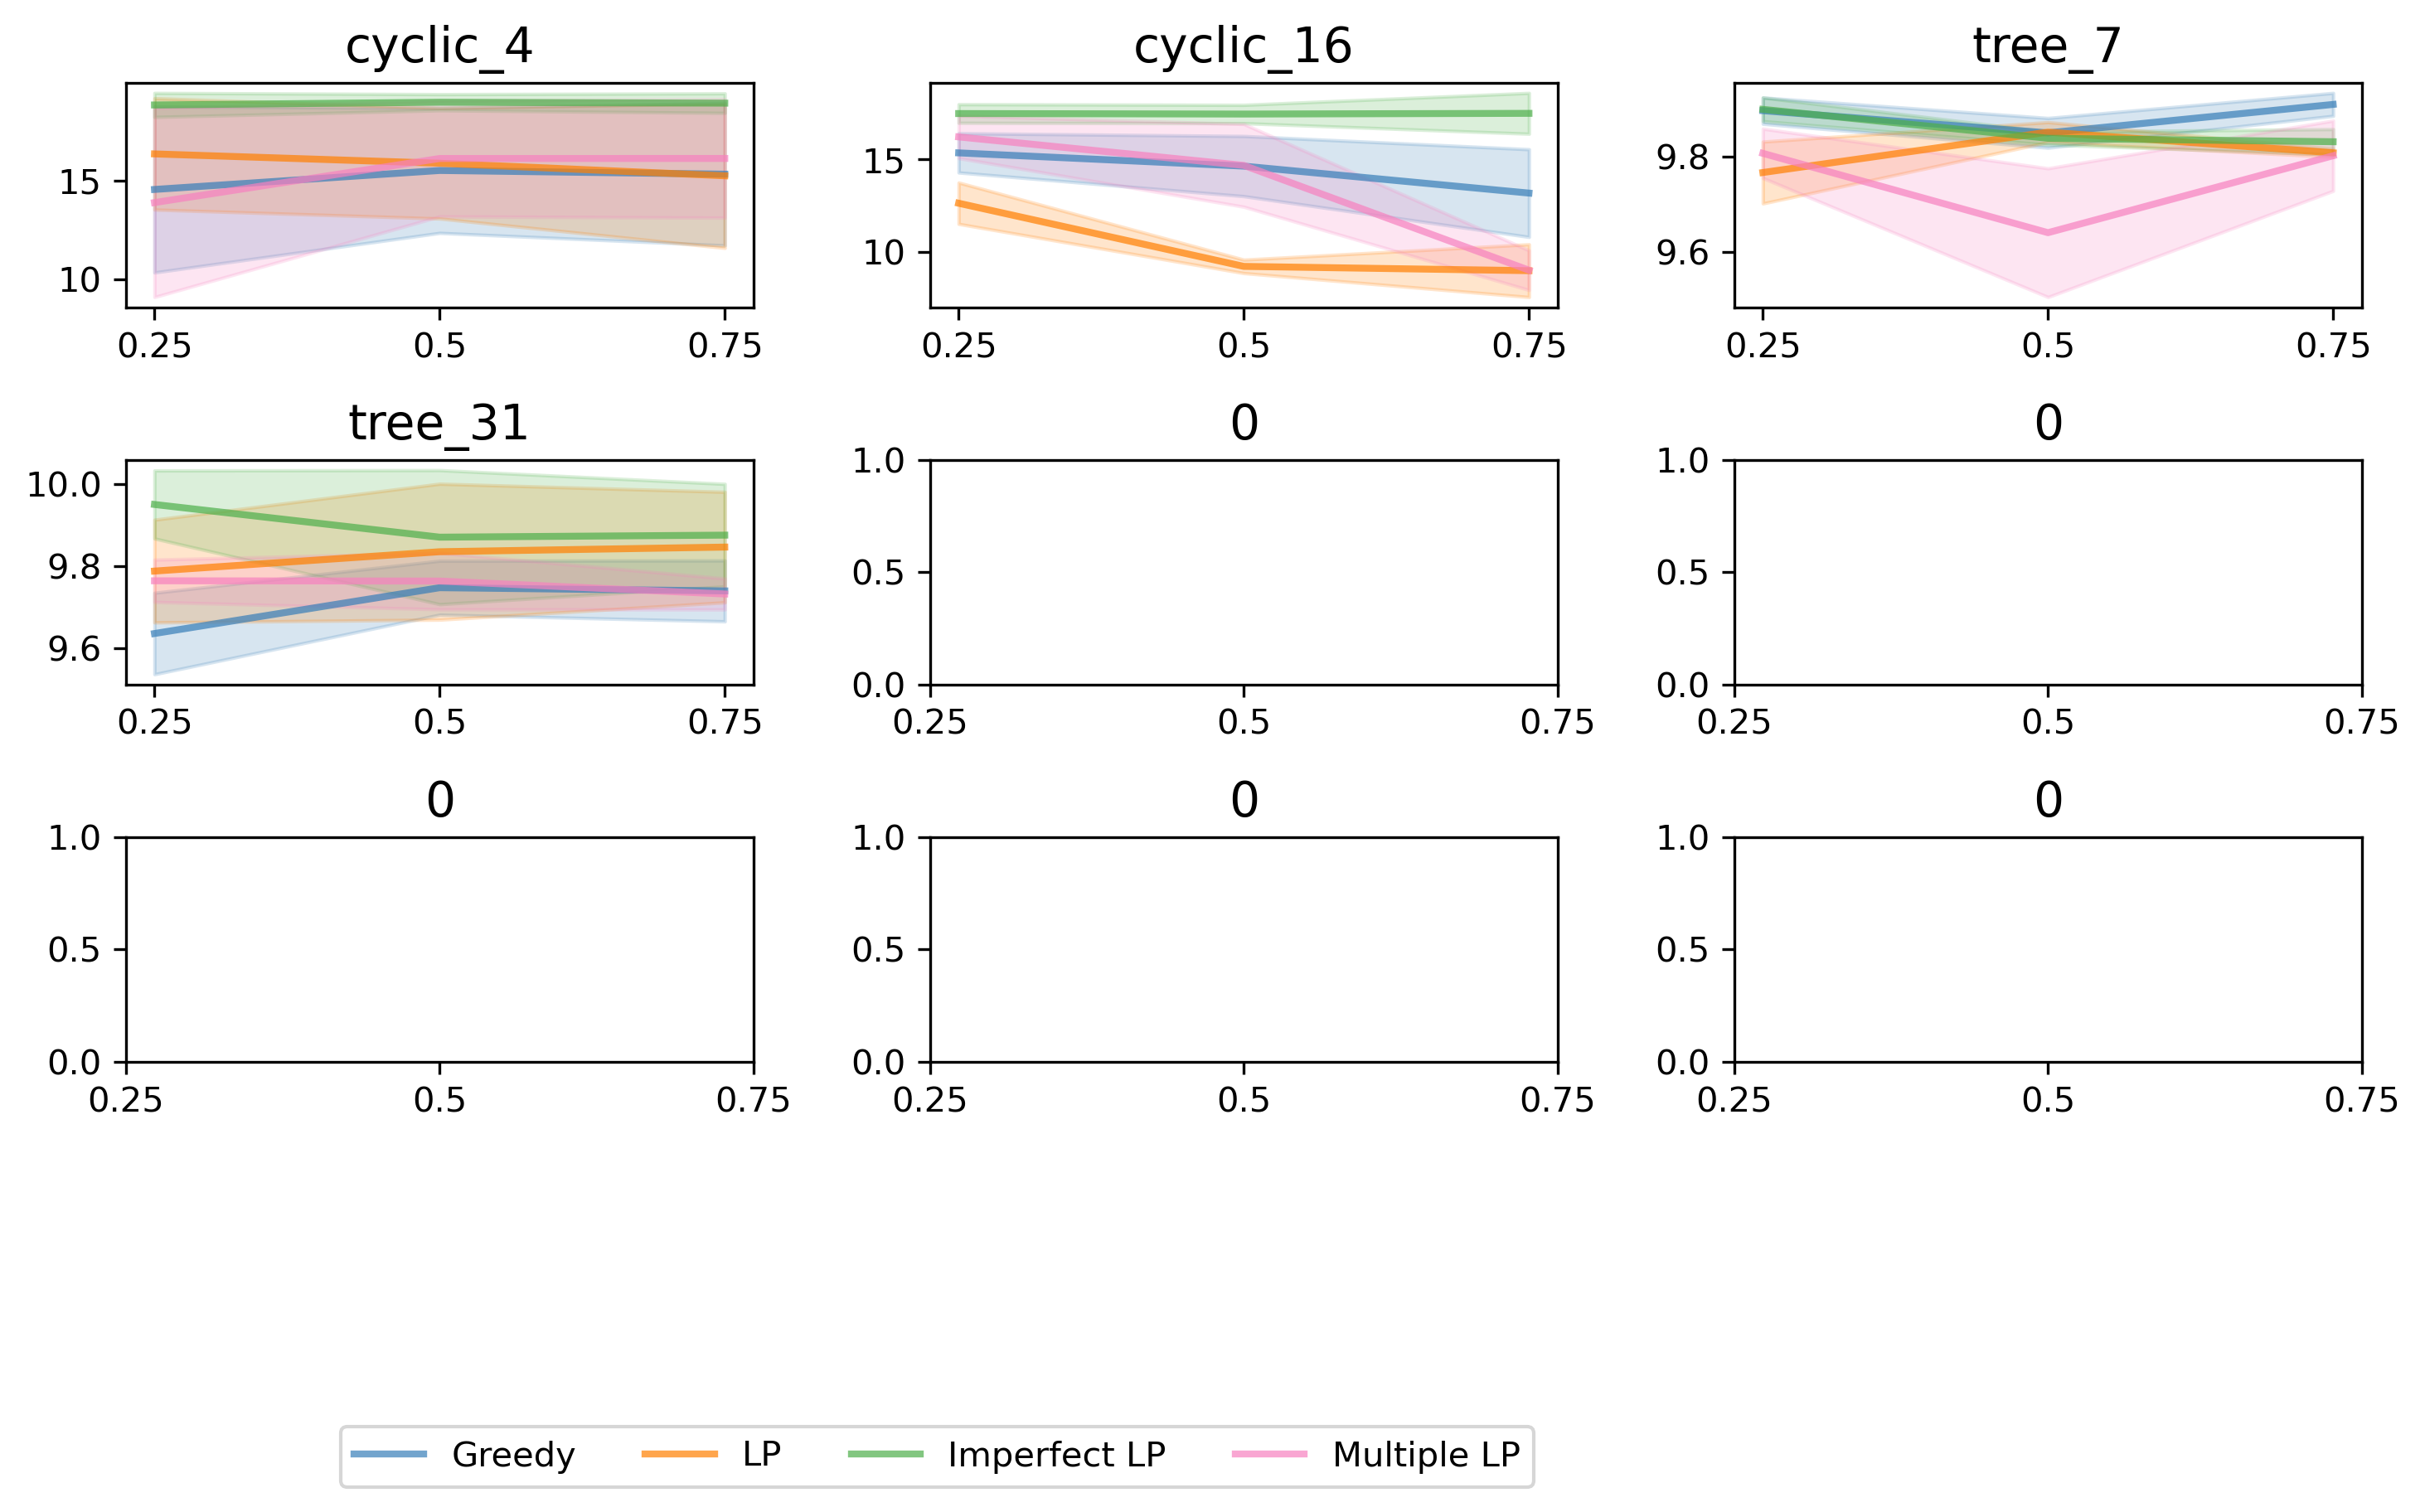

In [19]:
# Plot #concpet perf. 
# Plot Comparison for each env
plot_dimensions = (3,3)
def index_to_tuple(i):
    return (i//3,i%3)

def flatten_to_square(lst):
    res = [[0 for i in range(3)] for j in range(3)]

    for i in range(len(lst)):
        x,y = index_to_tuple(i)
        res[x][y] = lst[i]
    
    return res

titles = flatten_to_square(environments)

sup_y_label = ""
overall_format = {'figsize':(10,5),
    'style_size': style_size,
    'has_grid': False, 
    'x_ticks': [[[list(range(len(intervention_probability))),intervention_probability] for i in range(3)] for j in range(3)]

}

fig,ax = create_axes(plot_dimensions,overall_format,titles=titles)

line_format = {'color_palette': 'six_color', 'linewidth': 2}
plt.tight_layout()

all_labels = ["Greedy","LP","Imperfect LP","Multiple LP"]

for i in range(len(environments)):
    x_groups = [list(range(len(arr[i]))) for arr in [greedy_selection,lp_selection,imperfect_selection,multiple_selection]]
    x_vals = num_concepts_selected[i]
    y_vals = [[np.mean(arr[i][j]) for j in range(len(arr[i]))] for arr in [greedy_selection,lp_selection,imperfect_selection,multiple_selection]]
    y_std = [[np.std(arr[i][j])/len(arr[i][j])**.5 for j in range(len(arr[i]))] for arr in [greedy_selection,lp_selection,imperfect_selection,multiple_selection]]
    x,y = index_to_tuple(i)
    plot_line(ax[x][y],x_groups,y_vals,y_std,all_labels,line_format)

legend_format = {'style_size': style_size,'type': 'is_global', 'loc': 'lower left', 'ncol': 4, 'bbox_to_anchor': (0.15,-0.25),'fontsize': 14}
create_legend(fig,ax,plot_dimensions,legend_format)
fig.savefig("../../results/figures/intervention_comparison.pdf",dpi=300, bbox_inches='tight')

## Iterative Experiments

In [10]:
# Investigating Selected Pong Concepts
environments = ["cyclic_4","cyclic_16","tree_7","tree_31"]
num_iterations = 2

perf_by_iteration = [[0 for i in range(num_iterations)] for j in environments]
bayesian_by_iteration = [[0 for i in range(num_iterations)] for j in environments]
for i,e in enumerate(environments):
    matching_params = get_results_matching_parameters("iterative","",{'environment_string': e,'num_iterations': num_iterations,'selections_per_round': 1})
    if len(matching_params) > 0:
        perf_by_iteration[i] = [[m['iterative']['iterative_selection']['reward'][i] for m in matching_params] for i in range(num_iterations)]
        bayesian_by_iteration[i] = [[m['iterative']['bayesian']['reward'][i] for m in matching_params] for i in range(num_iterations)]

/tmp/ipykernel_2076873/1153119264.py:27: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  plt.tight_layout()


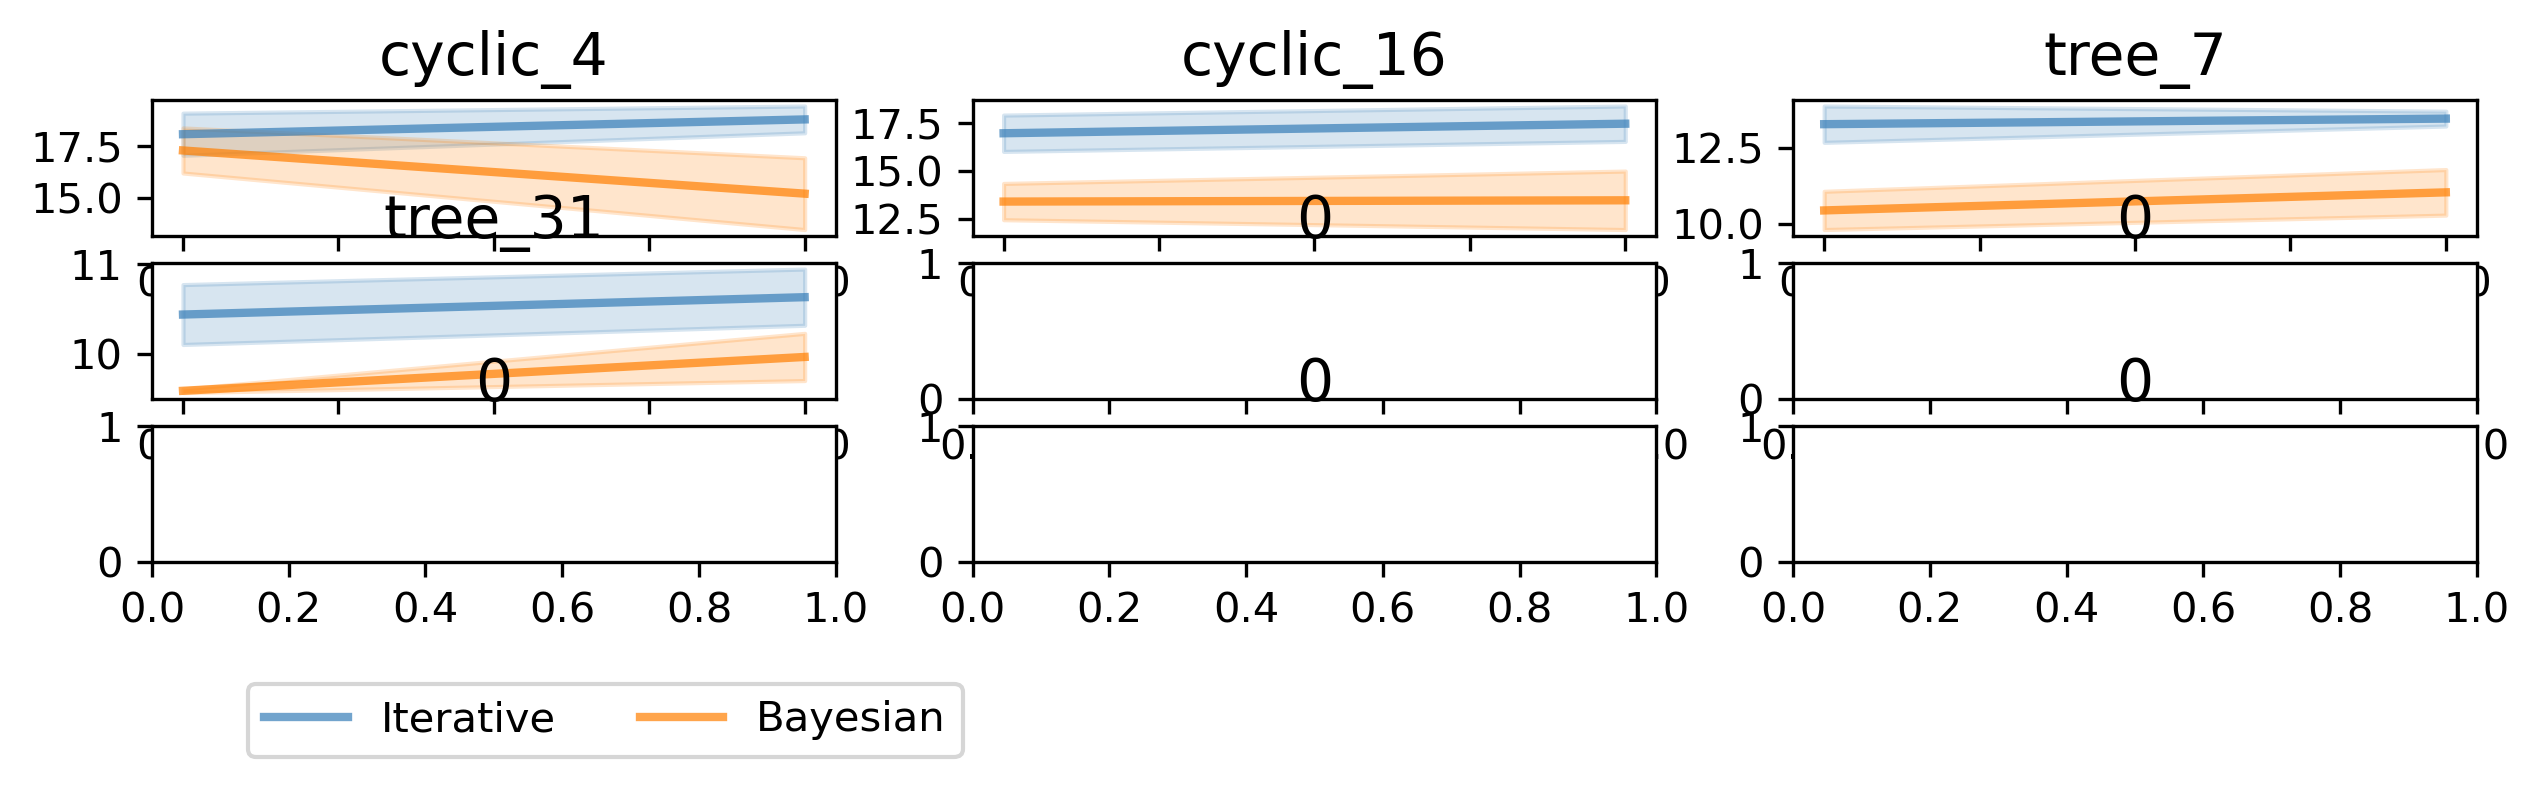

In [11]:
# Plot #concpet perf. 
# Plot Comparison for each env
plot_dimensions = (3,3)
def index_to_tuple(i):
    return (i//3,i%3)

def flatten_to_square(lst):
    res = [[0 for i in range(3)] for j in range(3)]

    for i in range(len(lst)):
        x,y = index_to_tuple(i)
        res[x][y] = lst[i]
    
    return res

titles = flatten_to_square(environments)

sup_y_label = ""
overall_format = {'figsize':(10,2),
    'style_size': style_size,
    'has_grid': False, 
}

fig,ax = create_axes(plot_dimensions,overall_format,titles=titles)

line_format = {'color_palette': 'six_color', 'linewidth': 2}
plt.tight_layout()

all_labels = ["Iterative","Bayesian"]

for i in range(len(environments)):
    x_groups = [list(range(len(arr[0]))) for arr in [perf_by_iteration,bayesian_by_iteration]]
    x_vals = list(range(1,num_iterations+1))
    y_vals = [[np.mean(arr[i][j]) for j in range(len(arr[i]))] for arr in [perf_by_iteration,bayesian_by_iteration]]
    x,y = index_to_tuple(i)
    y_std = [[np.std(arr[i][j])/len(arr[i][j])**.5 for j in range(len(arr[i]))] for arr in [perf_by_iteration,bayesian_by_iteration]]

    plot_line(ax[x][y],x_groups,y_vals,y_std,all_labels,line_format)

legend_format = {'style_size': style_size,'type': 'is_global', 'loc': 'lower left', 'ncol': 4, 'bbox_to_anchor': (0.15,-0.25),'fontsize': 14}
create_legend(fig,ax,plot_dimensions,legend_format)
fig.savefig("../../results/figures/iterative.pdf",dpi=300, bbox_inches='tight')

In [17]:
# Investigating Selected Pong Concepts
environments = ["cyclic_4","cyclic_16","tree_7","tree_31"]
num_concepts = [3,15,4,6]
num_iterations = 2

perf_by_iteration = [[0 for i in range(num_iterations)] for j in environments]
bayesian_by_iteration = [[0 for i in range(num_iterations)] for j in environments]
for i,e in enumerate(environments):
    matching_params = get_results_matching_parameters("iterative","",{'environment_string': e,'num_iterations': num_iterations,'selections_per_round': 1, 'cbm_accuracy_by_concept': [0.75 for i in range(num_concepts[i])]})
    if len(matching_params) > 0:
        perf_by_iteration[i] = [[m['iterative']['iterative_selection']['reward'][i] for m in matching_params] for i in range(num_iterations)]
        bayesian_by_iteration[i] = [[m['iterative']['bayesian']['reward'][i] for m in matching_params] for i in range(num_iterations)]

/tmp/ipykernel_2076873/1153119264.py:27: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  plt.tight_layout()


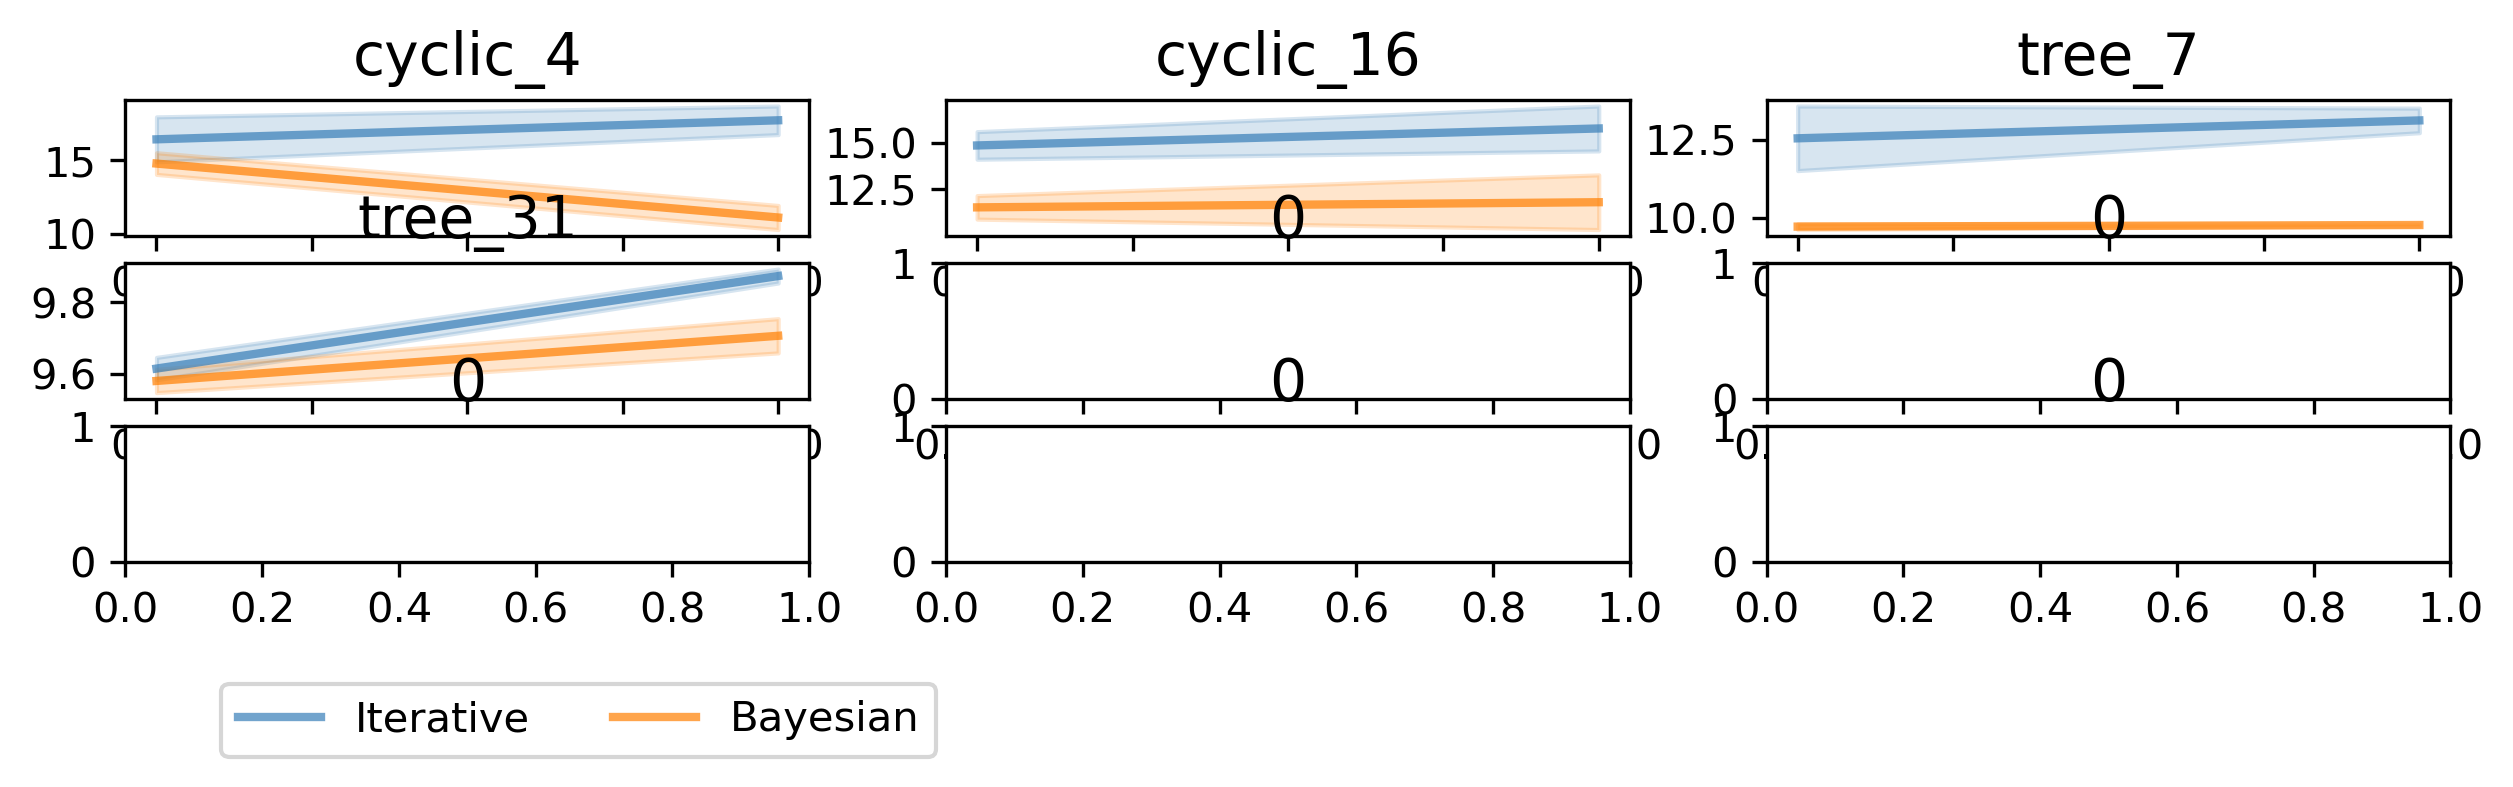

In [18]:
# Plot #concpet perf. 
# Plot Comparison for each env
plot_dimensions = (3,3)
def index_to_tuple(i):
    return (i//3,i%3)

def flatten_to_square(lst):
    res = [[0 for i in range(3)] for j in range(3)]

    for i in range(len(lst)):
        x,y = index_to_tuple(i)
        res[x][y] = lst[i]
    
    return res

titles = flatten_to_square(environments)

sup_y_label = ""
overall_format = {'figsize':(10,2),
    'style_size': style_size,
    'has_grid': False, 
}

fig,ax = create_axes(plot_dimensions,overall_format,titles=titles)

line_format = {'color_palette': 'six_color', 'linewidth': 2}
plt.tight_layout()

all_labels = ["Iterative","Bayesian"]

for i in range(len(environments)):
    x_groups = [list(range(len(arr[0]))) for arr in [perf_by_iteration,bayesian_by_iteration]]
    x_vals = list(range(1,num_iterations+1))
    y_vals = [[np.mean(arr[i][j]) for j in range(len(arr[i]))] for arr in [perf_by_iteration,bayesian_by_iteration]]
    x,y = index_to_tuple(i)
    y_std = [[np.std(arr[i][j])/len(arr[i][j])**.5 for j in range(len(arr[i]))] for arr in [perf_by_iteration,bayesian_by_iteration]]

    plot_line(ax[x][y],x_groups,y_vals,y_std,all_labels,line_format)

legend_format = {'style_size': style_size,'type': 'is_global', 'loc': 'lower left', 'ncol': 4, 'bbox_to_anchor': (0.15,-0.25),'fontsize': 14}
create_legend(fig,ax,plot_dimensions,legend_format)
fig.savefig("../../results/figures/iterative.pdf",dpi=300, bbox_inches='tight')

## CUB Experiments

In [7]:
matching_params = get_results_matching_parameters("cub","",{'num_concepts_selected': 40})

In [8]:
perfect_lp = [[m['perfect']['lp'][str(c)]['reward'] for c in [10,20,30,40,50,60,70,80,90,100,110]] for m in matching_params]
chosen_concepts = np.mean([m['perfect']['manual']['reward'] for m in matching_params])
similarity = [len(set(matching_params[0]['perfect']['lp'][str(c)]['concepts']).intersection(set(matching_params[0]['perfect']['manual']['concepts'])))/c for c in [10,20,30,40,50,60,70,80,90,100,110]]
perfect_lp = np.mean(perfect_lp,axis=0)

/tmp/ipykernel_1488062/3540731849.py:16: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


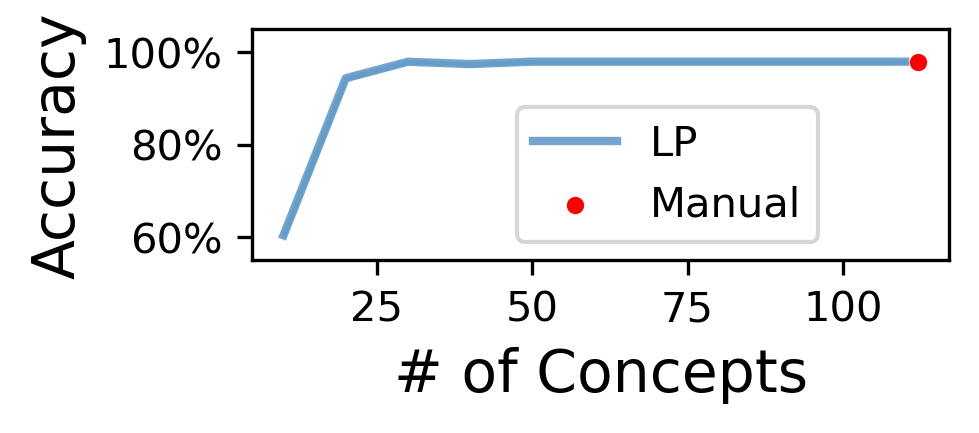

In [9]:
# Plot #concpet perf. 
# Plot Comparison for each env
plot_dimensions = (1,1)

sup_y_label = ""
overall_format = {'figsize':(3,1),
    'style_size': style_size,
    'has_grid': False, 
    'y_ticks': [[[[0.6,0.8,1],["60%","80%","100%"]]]],
    'y_lim': [[[0.55,1.05]]]
}

fig,ax = create_axes(plot_dimensions,overall_format,x_labels=[["# of Concepts"]],y_labels=[["Accuracy"]])

line_format = {'color_palette': 'six_color', 'linewidth': 2}
plt.tight_layout()

all_labels = ["LP","Manual"]

x_groups = [list(range(10,119,10))]
y_vals = [[perfect_lp[min(i,len(perfect_lp)-1)] for i in range(len(x_groups[0]))]]

plot_line(ax[0][0],x_groups,y_vals,[[0 for i in range(len(arr))] for arr in y_vals],all_labels,line_format)
plt.scatter([112],[chosen_concepts],s=10,c='red',label="Manual")

legend_format = {'style_size': style_size,'type': 'is_local', 'loc': 'lower left', 'ncol': 1, 'bbox_to_anchor': (0.35,-0.01),'fontsize': 10}
create_legend(fig,ax,plot_dimensions,legend_format)
fig.savefig("../../results/figures/perfect_cub.pdf",dpi=300, bbox_inches='tight')

/tmp/ipykernel_1488062/3247213190.py:15: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


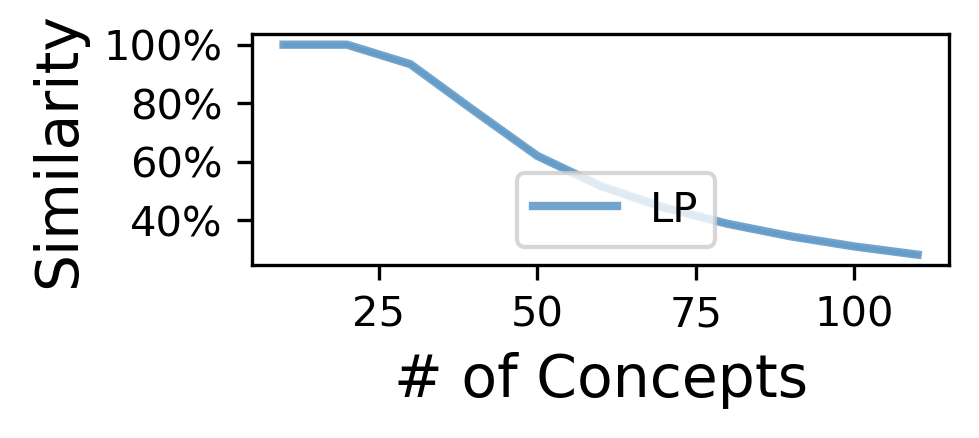

In [10]:
# Plot #concpet perf. 
# Plot Comparison for each env
plot_dimensions = (1,1)

sup_y_label = ""
overall_format = {'figsize':(3,1),
    'style_size': style_size,
    'has_grid': False, 
    'y_ticks': [[[[0.2,0.4,0.6,0.8,1],["20%","40%","60%","80%","100%"]]]]
}

fig,ax = create_axes(plot_dimensions,overall_format,x_labels=[["# of Concepts"]],y_labels=[["Similarity"]])

line_format = {'color_palette': 'six_color', 'linewidth': 2}
plt.tight_layout()

all_labels = ["LP","Manual"]

x_groups = [list(range(10,119,10))]
y_vals = [[similarity[min(i,len(perfect_lp)-1)] for i in range(len(x_groups[0]))]]

plot_line(ax[0][0],x_groups,y_vals,[[0 for i in range(len(arr))] for arr in y_vals],all_labels,line_format)

legend_format = {'style_size': style_size,'type': 'is_local', 'loc': 'lower left', 'ncol': 1, 'bbox_to_anchor': (0.35,-0.01),'fontsize': 10}
create_legend(fig,ax,plot_dimensions,legend_format)
fig.savefig("../../results/figures/similarity_cub.pdf",dpi=300, bbox_inches='tight')

In [11]:
imperfect_lp = [[m['imperfect']['lp'][str(c)]['reward'] for c in [10,20,30,40,50,60,70,80,90,100,110]] for m in matching_params]
imperfect_lp = np.mean(imperfect_lp,axis=0)
multiple_lp = [[m['imperfect']['multiple_lp'][str(c)]['reward'] for c in [10,20,30,40,50,60,70,80,90,100,110]] for m in matching_params]
multiple_lp = np.mean(multiple_lp,axis=0)

chosen_concepts = np.mean([m['imperfect']['manual']['reward'] for m in matching_params])


/tmp/ipykernel_1488062/2657331554.py:15: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


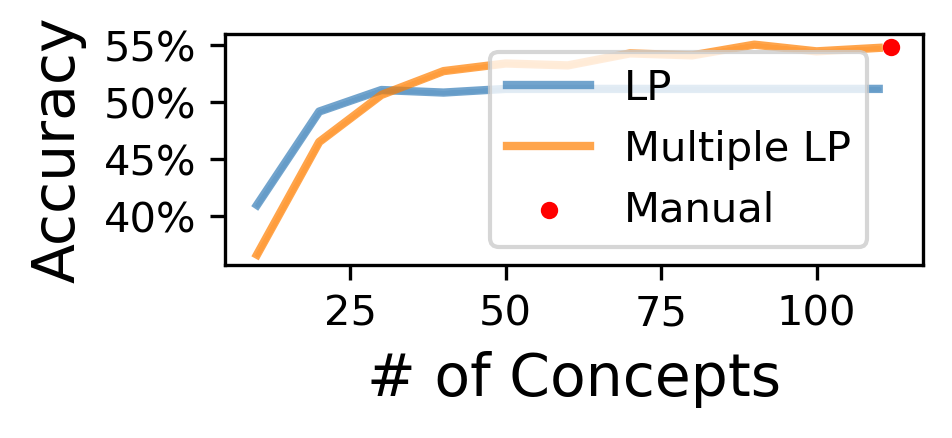

In [12]:
# Plot #concpet perf. 
# Plot Comparison for each env
plot_dimensions = (1,1)

sup_y_label = ""
overall_format = {'figsize':(3,1),
    'style_size': style_size,
    'has_grid': False, 
    'y_ticks': [[[[0.4,0.45,0.5,0.55],["40%","45%","50%","55%"]]]]
}

fig,ax = create_axes(plot_dimensions,overall_format,x_labels=[["# of Concepts"]],y_labels=[["Accuracy"]])

line_format = {'color_palette': 'six_color', 'linewidth': 2}
plt.tight_layout()

all_labels = ["LP","Multiple LP"]

x_groups = [list(range(10,119,10)),list(range(10,119,10))]
y_vals = [[imperfect_lp[min(i,len(imperfect_lp)-1)] for i in range(len(x_groups[0]))],[multiple_lp[min(i,len(multiple_lp)-1)] for i in range(len(x_groups[0]))]]

plot_line(ax[0][0],x_groups,y_vals,[[0 for i in range(len(arr))] for arr in y_vals],all_labels,line_format)
plt.scatter([112],[chosen_concepts],s=10,c='red',label="Manual")

legend_format = {'style_size': style_size,'type': 'is_local', 'loc': 'lower left', 'ncol': 1, 'bbox_to_anchor': (0.35,-0.01),'fontsize': 10}
create_legend(fig,ax,plot_dimensions,legend_format)
fig.savefig("../../results/figures/imperfect_cub.pdf",dpi=300, bbox_inches='tight')

In [13]:
similarity_multiple = [len(set(matching_params[0]['imperfect']['multiple_lp'][str(c)]['concepts']).intersection(set(matching_params[0]['perfect']['manual']['concepts'])))/c for c in [10,20,30,40,50,60,70,80,90,100,110]]
similarity = [len(set(matching_params[0]['perfect']['lp'][str(c)]['concepts']).intersection(set(matching_params[0]['perfect']['manual']['concepts'])))/c for c in [10,20,30,40,50,60,70,80,90,100,110]]

/tmp/ipykernel_1488062/3471022662.py:15: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


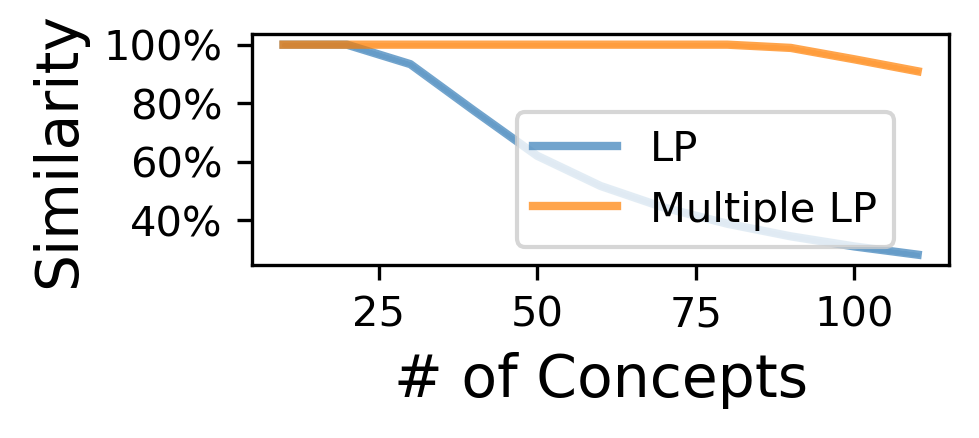

In [14]:
# Plot #concpet perf. 
# Plot Comparison for each env
plot_dimensions = (1,1)

sup_y_label = ""
overall_format = {'figsize':(3,1),
    'style_size': style_size,
    'has_grid': False, 
    'y_ticks': [[[[0.4,0.6,0.8,1],["40%","60%","80%","100%"]]]]
}

fig,ax = create_axes(plot_dimensions,overall_format,x_labels=[["# of Concepts"]],y_labels=[["Similarity"]])

line_format = {'color_palette': 'six_color', 'linewidth': 2}
plt.tight_layout()

all_labels = ["LP","Multiple LP"]

x_groups = [list(range(10,119,10)),list(range(10,119,10))]
y_vals = [[similarity[min(i,len(similarity)-1)] for i in range(len(x_groups[0]))],[similarity_multiple[min(i,len(similarity_multiple)-1)] for i in range(len(x_groups[0]))]]

plot_line(ax[0][0],x_groups,y_vals,[[0 for i in range(len(arr))] for arr in y_vals],all_labels,line_format)

legend_format = {'style_size': style_size,'type': 'is_local', 'loc': 'lower left', 'ncol': 1, 'bbox_to_anchor': (0.35,-0.01),'fontsize': 10}
create_legend(fig,ax,plot_dimensions,legend_format)
fig.savefig("../../results/figures/similarity_cub.pdf",dpi=300, bbox_inches='tight')

## Ablation Studies